In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

In [26]:
df = pd.read_csv('dados/df_final.csv')
df.head(3)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DEST_AIRPORT_NAME,DEST_CITY,DEST_STATE,DEST_COUNTRY,DEST_LATITUDE,DEST_LONGITUDE,dia_semana,hora_partida
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,61.17432,-149.99619,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931,Quinta,0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,33.94254,-118.40807,Palm Beach International Airport,West Palm Beach,FL,USA,26.68316,-80.09559,Quinta,0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,37.61900,-122.37484,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313,Quinta,0


### Quantas variáveis existem no dataset e de quais tipos são?

In [28]:
print(f"Total de variáveis: {df.shape[1]}\n")
print(f"Total de registros: {df.shape[0]}\n")

Total de variáveis: 46

Total de registros: 5819079



In [30]:
print(df.dtypes.value_counts().to_string())

float64    20
str        13
int64      11
object      2


In [32]:
# Converter as colunas do tipo object para string
obj_cols = df.select_dtypes(include='object').columns
df[obj_cols] = df[obj_cols].astype('string')

print(df.dtypes.value_counts())

float64    20
string     15
int64      11
Name: count, dtype: int64


In [33]:
print(df.dtypes.to_string())

YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 string
FLIGHT_NUMBER            int64
TAIL_NUMBER             string
ORIGIN_AIRPORT          string
DESTINATION_AIRPORT     string
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE                 int64
WHEELS_ON              float64
TAXI_IN                float64
SCHEDULED_ARRIVAL        int64
ARRIVAL_TIME           float64
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON     string
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
AIRLINE_NAME            string
ORIGIN_A

In [24]:
df["ORIGIN_AIRPORT"].unique()

array(['ANC', 'LAX', 'SFO', 'SEA', 'LAS', 'DEN', 'SLC', 'PDX', 'FAI',
       'MSP', 'PHX', 'SJU', 'PBG', 'IAG', 'PSE', 'BQN', 'ORD', 'GEG',
       'HNL', 'ONT', 'MCO', 'BOS', 'HIB', 'ABR', 'MAF', 'DFW', 'MKE',
       'IAH', 'BNA', 'BRO', 'VPS', 'BOI', 'BJI', 'SGF', 'PHL', 'SBN',
       'RDD', 'EUG', 'IAD', 'BUF', 'PWM', 'JFK', 'CRP', 'PIA', 'FAT',
       'SMF', 'AUS', 'MCI', 'ATL', 'JAX', 'MFR', 'IDA', 'MSN', 'DCA',
       'SAT', 'CHS', 'SBA', 'SMX', 'IND', 'CLE', 'GSP', 'BDL', 'ABI',
       'RIC', 'BFL', 'OMA', 'RDM', 'FLL', 'CID', 'TPA', 'SYR', 'ROC',
       'TYR', 'LAN', 'XNA', 'GSO', 'EWR', 'PBI', 'RSW', 'OAK', 'PVD',
       'RNO', 'PIT', 'ABQ', 'MIA', 'BWI', 'LGA', 'TUL', 'LIT', 'MSY',
       'OKC', 'ATW', 'PNS', 'MEM', 'TYS', 'MHT', 'SAV', 'CLT', 'GRB',
       'ABE', 'JAN', 'OAJ', 'FAR', 'ERI', 'LEX', 'CWA', 'MSO', 'TTN',
       'AMA', 'CLL', 'HOU', 'JLN', 'MLI', 'RDU', 'CVG', 'MHK', 'MOB',
       'TLH', 'BHM', 'CAE', 'TXK', 'ACY', 'DTW', 'RAP', 'TUS', 'EAU',
       'DLH', 'FSD',

In [23]:
df["TAIL_NUMBER"].unique()

<StringArray>
['N407AS', 'N3KUAA', 'N171US', 'N3HYAA', 'N527AS', 'N3730B', 'N635NK',
 'N584UW', 'N3LAAA', 'N826DN',
 ...
 'N7LCAA', 'N885AA', 'N7833A', 'N662NK', 'N7LLAA', 'N8675A', 'N7LUAA',
 'N7LEAA', 'N850DN', 'N8676A']
Length: 4898, dtype: str

In [19]:
df["YEAR"].unique()

array([2015])

In [37]:
# Separar variáveis numéricas e categóricas
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='string').columns.tolist()

In [35]:
print(f"Variáveis numéricas ({len(num_cols)}):")
for c in num_cols:
    print(f"  • {c}")

Variáveis numéricas (31):
  • YEAR
  • MONTH
  • DAY
  • DAY_OF_WEEK
  • FLIGHT_NUMBER
  • SCHEDULED_DEPARTURE
  • DEPARTURE_TIME
  • DEPARTURE_DELAY
  • TAXI_OUT
  • WHEELS_OFF
  • SCHEDULED_TIME
  • ELAPSED_TIME
  • AIR_TIME
  • DISTANCE
  • WHEELS_ON
  • TAXI_IN
  • SCHEDULED_ARRIVAL
  • ARRIVAL_TIME
  • ARRIVAL_DELAY
  • DIVERTED
  • CANCELLED
  • AIR_SYSTEM_DELAY
  • SECURITY_DELAY
  • AIRLINE_DELAY
  • LATE_AIRCRAFT_DELAY
  • WEATHER_DELAY
  • ORIGIN_LATITUDE
  • ORIGIN_LONGITUDE
  • DEST_LATITUDE
  • DEST_LONGITUDE
  • hora_partida


In [38]:
print(f"\nVariáveis categóricas ({len(cat_cols)}):")
for c in cat_cols:
    print(f"  • {c}")


Variáveis categóricas (15):
  • AIRLINE
  • TAIL_NUMBER
  • ORIGIN_AIRPORT
  • DESTINATION_AIRPORT
  • CANCELLATION_REASON
  • AIRLINE_NAME
  • ORIGIN_AIRPORT_NAME
  • ORIGIN_CITY
  • ORIGIN_STATE
  • ORIGIN_COUNTRY
  • DEST_AIRPORT_NAME
  • DEST_CITY
  • DEST_STATE
  • DEST_COUNTRY
  • dia_semana


### Estatísticas descritivas gerais

In [39]:
# Describe completo das numéricas
df[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
YEAR,5819079.0,2015.00,0.00,2015.00,2015.00,2015.00,2015.00,2015.00
MONTH,5819079.0,6.52,3.41,1.00,4.00,7.00,9.00,12.00
DAY,5819079.0,15.70,8.78,1.00,8.00,16.00,23.00,31.00
DAY_OF_WEEK,5819079.0,3.93,1.99,1.00,2.00,4.00,6.00,7.00
FLIGHT_NUMBER,5819079.0,2173.09,1757.06,1.00,730.00,1690.00,3230.00,9855.00
SCHEDULED_DEPARTURE,5819079.0,1329.60,483.75,1.00,917.00,1325.00,1730.00,2359.00
DEPARTURE_TIME,5732926.0,1335.20,496.42,1.00,921.00,1330.00,1740.00,2400.00
DEPARTURE_DELAY,5732926.0,9.37,37.08,-82.00,-5.00,-2.00,7.00,1988.00
TAXI_OUT,5730032.0,16.07,8.90,1.00,11.00,14.00,19.00,225.00
WHEELS_OFF,5730032.0,1357.17,498.01,1.00,935.00,1343.00,1754.00,2400.00


In [40]:
# Describe das categóricas
df[cat_cols].describe().T

,count,unique,top,freq
AIRLINE,5819079,14,WN,1261855
TAIL_NUMBER,5804358,4897,N480HA,3768
ORIGIN_AIRPORT,5819079,628,ATL,346836
DESTINATION_AIRPORT,5819079,629,ATL,346904
CANCELLATION_REASON,89884,4,B,48851
AIRLINE_NAME,5819079,14,Southwest Airlines Co.,1261855
ORIGIN_AIRPORT_NAME,5332914,322,Hartsfield-Jackson Atlanta International Airport,346836
ORIGIN_CITY,5332914,308,Chicago,366770
ORIGIN_STATE,5332914,54,CA,647911
ORIGIN_COUNTRY,5332914,1,USA,5332914


### Criação dos targets de atraso

Vamos criar **dois targets binários** com threshold de **10 minutos**:

- `ATRASO_SAIDA` → 1 se `DEPARTURE_DELAY >= 10`, caso contrário 0
- `ATRASO_CHEGADA` → 1 se `ARRIVAL_DELAY >= 10`, caso contrário 0

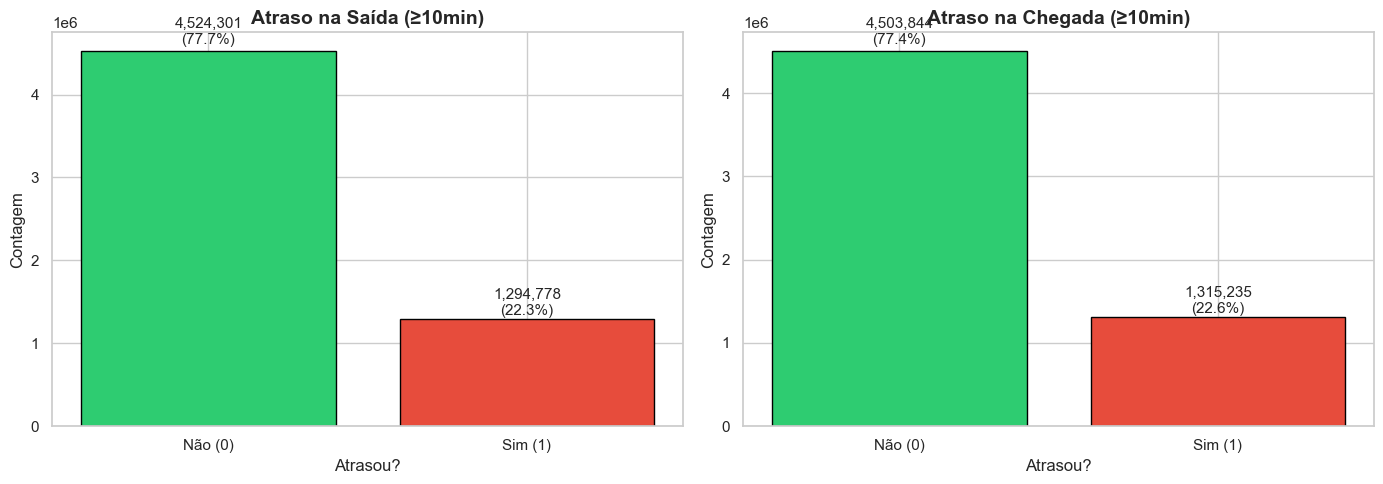


Concordância entre os dois targets: 89.3%


In [43]:
THRESHOLD = 10  # minutos

df['ATRASO_SAIDA']   = (df['DEPARTURE_DELAY'] >= THRESHOLD).astype(int)
df['ATRASO_CHEGADA'] = (df['ARRIVAL_DELAY']   >= THRESHOLD).astype(int)

# Distribuição dos targets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
                           ['ATRASO_SAIDA', 'ATRASO_CHEGADA'],
                           [f'Atraso na Saída (≥{THRESHOLD}min)', f'Atraso na Chegada (≥{THRESHOLD}min)']):
    counts = df[col].value_counts().sort_index()
    bars = ax.bar(counts.index.astype(str), counts.values,
                  color=['#2ecc71', '#e74c3c'], edgecolor='black')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Atrasou?')
    ax.set_ylabel('Contagem')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Não (0)', 'Sim (1)'])
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + h*0.01,
                f'{h:,.0f}\n({h/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

concordancia = (df['ATRASO_SAIDA'] == df['ATRASO_CHEGADA']).mean()
print(f"\nConcordância entre os dois targets: {concordancia:.1%}")

### Distribuição das variáveis numéricas e detecção de outliers

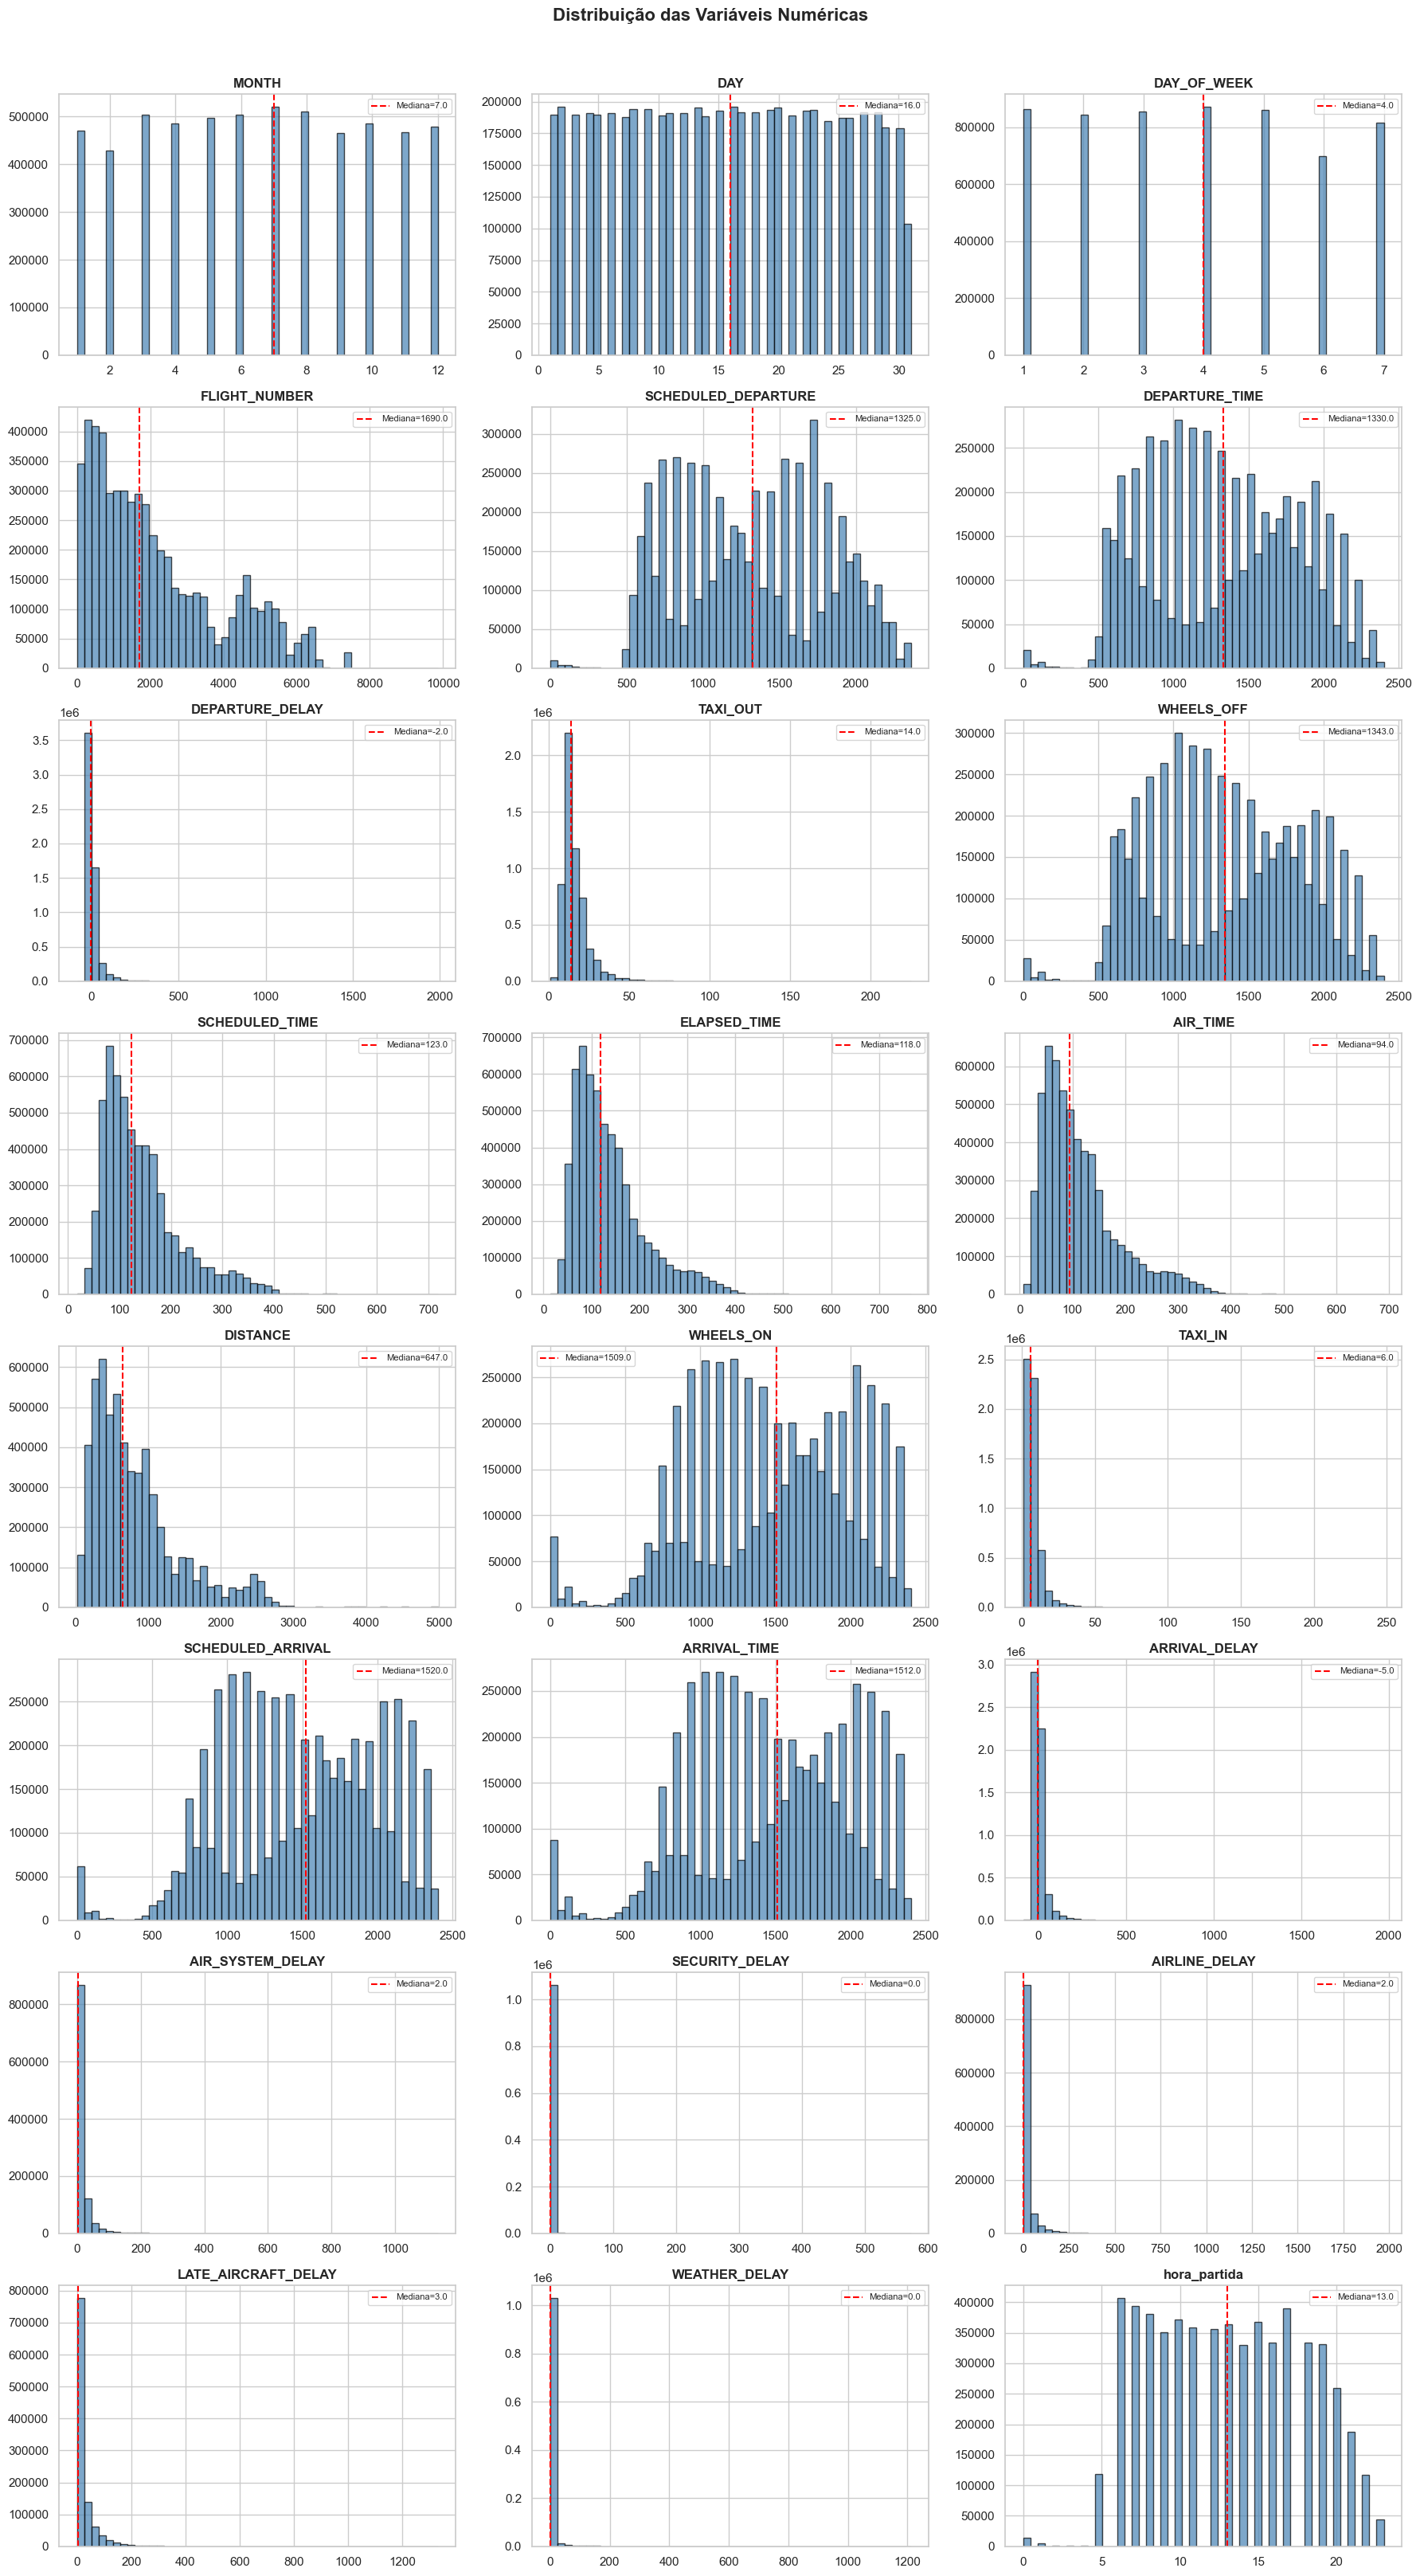

In [7]:
# Excluir colunas de identificação / coordenadas / targets para foco nas features
cols_excluir_hist = ['YEAR', 'ORIGIN_LATITUDE', 'ORIGIN_LONGITUDE',
                     'DEST_LATITUDE', 'DEST_LONGITUDE',
                     'DIVERTED', 'CANCELLED', 'ATRASO_SAIDA', 'ATRASO_CHEGADA']
num_features = [c for c in num_cols if c not in cols_excluir_hist]

n = len(num_features)
ncols_plot = 3
nrows_plot = int(np.ceil(n / ncols_plot))

fig, axes = plt.subplots(nrows_plot, ncols_plot, figsize=(18, 4 * nrows_plot))
axes = axes.flatten()

for i, col in enumerate(num_features):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(data.median(), color='red', linestyle='--', label=f'Mediana={data.median():.1f}')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

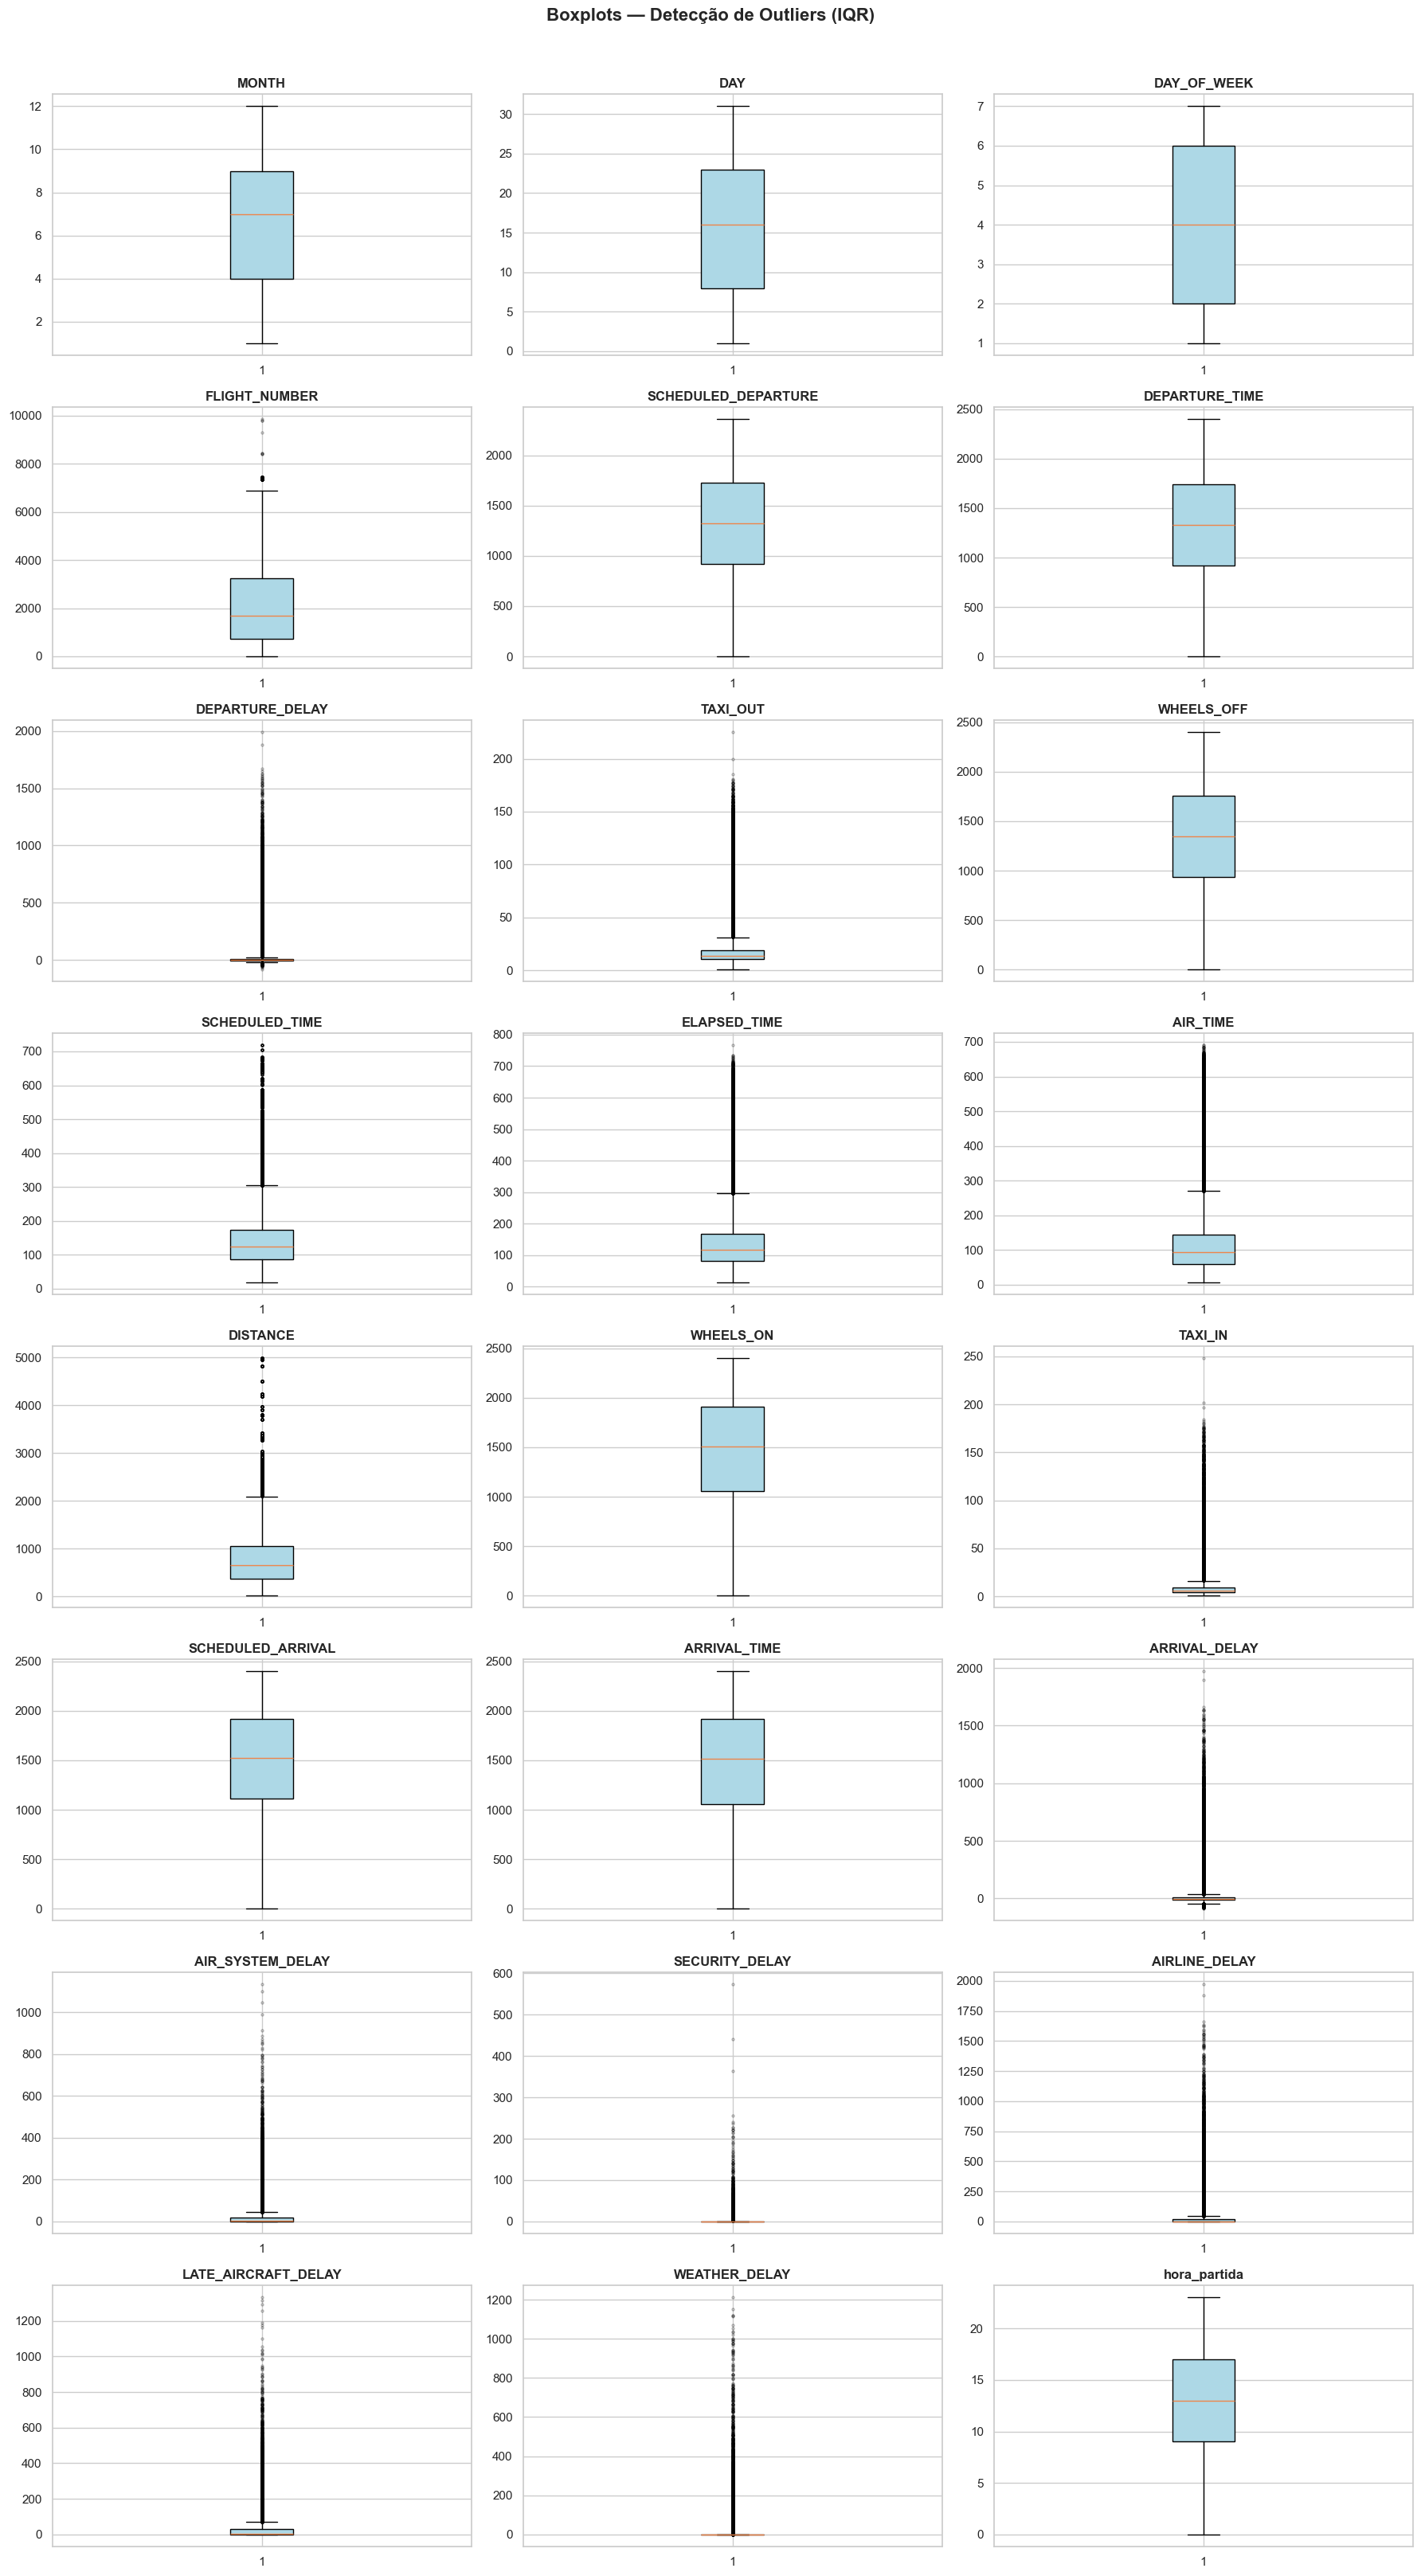

In [8]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(nrows_plot, ncols_plot, figsize=(18, 4 * nrows_plot))
axes = axes.flatten()

outlier_summary = []

for i, col in enumerate(num_features):
    ax = axes[i]
    data = df[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue', edgecolor='black'),
               flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title(col, fontsize=12, fontweight='bold')

    # IQR outlier count
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((data < lower) | (data > upper)).sum()
    pct_outliers = n_outliers / len(data) * 100
    outlier_summary.append({'Variável': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                            'Limite_Inf': lower, 'Limite_Sup': upper,
                            'N_Outliers': n_outliers, '%_Outliers': round(pct_outliers, 2)})

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Detecção de Outliers (IQR)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# Tabela resumo de outliers
df_outliers = pd.DataFrame(outlier_summary).sort_values('%_Outliers', ascending=False)
df_outliers.style.background_gradient(subset=['%_Outliers'], cmap='Reds')

,Variável,Q1,Q3,IQR,Limite_Inf,Limite_Sup,N_Outliers,%_Outliers
6,DEPARTURE_DELAY,-5.000000,7.000000,12.000000,-23.000000,25.000000,736242,12.840000
20,AIRLINE_DELAY,0.000000,19.000000,19.000000,-28.500000,47.500000,112616,10.590000
21,LATE_AIRCRAFT_DELAY,0.000000,29.000000,29.000000,-43.500000,72.500000,100733,9.470000
17,ARRIVAL_DELAY,-13.000000,8.000000,21.000000,-44.500000,39.500000,512002,8.960000
18,AIR_SYSTEM_DELAY,0.000000,18.000000,18.000000,-27.000000,45.000000,73597,6.920000
22,WEATHER_DELAY,0.000000,0.000000,0.000000,0.000000,0.000000,64716,6.090000
12,DISTANCE,373.000000,1062.000000,689.000000,-660.500000,2095.500000,349511,6.010000
11,AIR_TIME,60.000000,144.000000,84.000000,-66.000000,270.000000,296342,5.190000
9,SCHEDULED_TIME,85.000000,173.000000,88.000000,-47.000000,305.000000,299011,5.140000
10,ELAPSED_TIME,82.000000,168.000000,86.000000,-47.000000,297.000000,291084,5.090000


### Volume por categoria das variáveis categóricas

Verificar se existem categorias com frequência muito baixa que devam ser agrupadas ou descartadas.

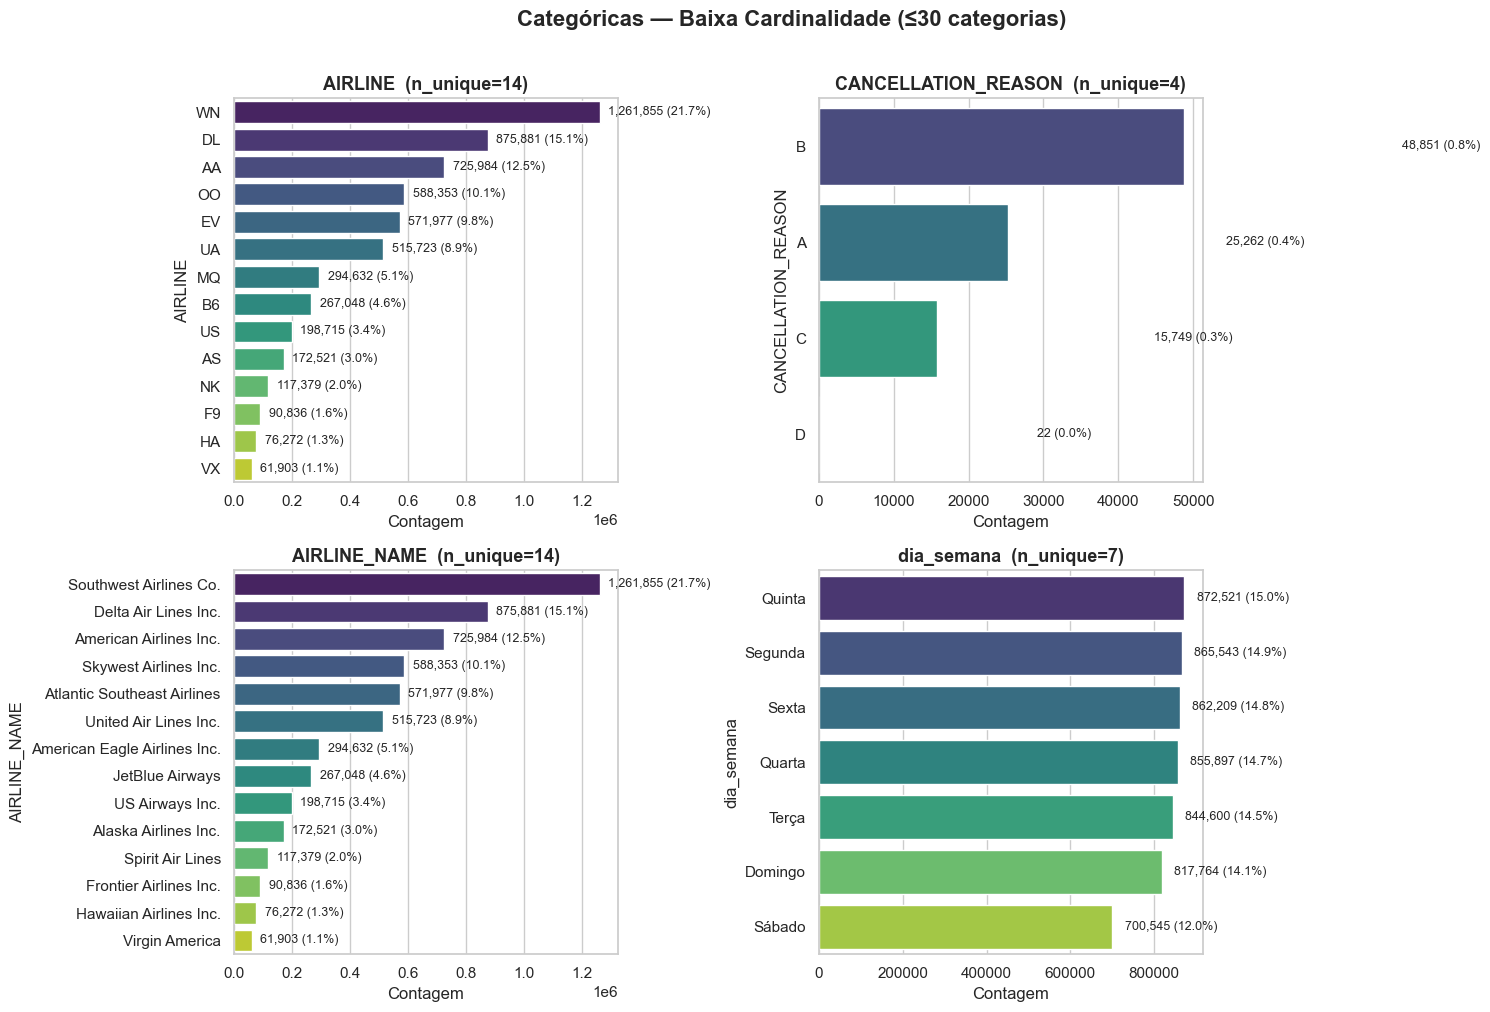

In [45]:
# Categóricas com poucas categorias — barplot
cat_cols = [c for c in cat_cols if c not in ["DEST_COUNTRY", "ORIGIN_COUNTRY", "TAIL_NUMBER", "YEAR"]]
cat_low_card = [c for c in cat_cols if df[c].nunique() <= 30]
cat_high_card = [c for c in cat_cols if df[c].nunique() > 30]

n = len(cat_low_card)
if n > 0:
    ncols_p = 2
    nrows_p = int(np.ceil(n / ncols_p))
    fig, axes = plt.subplots(nrows_p, ncols_p, figsize=(16, 5 * nrows_p))
    axes = axes.flatten() if n > 1 else [axes]

    for i, col in enumerate(cat_low_card):
        ax = axes[i]
        order = df[col].value_counts().index
        sns.countplot(data=df, y=col, order=order, ax=ax, palette='viridis')
        ax.set_title(f'{col}  (n_unique={df[col].nunique()})', fontsize=13, fontweight='bold')
        ax.set_xlabel('Contagem')
        # Adicionar percentual
        total = len(df)
        for p in ax.patches:
            w = p.get_width()
            ax.text(w + total*0.005, p.get_y() + p.get_height()/2,
                    f'{w:,.0f} ({w/total*100:.1f}%)', va='center', fontsize=9)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Categóricas — Baixa Cardinalidade (≤30 categorias)',
                 fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


ORIGIN_AIRPORT  —  628 categorias únicas
Top 20:
ORIGIN_AIRPORT
ATL    346836
ORD    285884
DFW    239551
DEN    196055
LAX    194673
SFO    148008
PHX    146815
IAH    146622
LAS    133181
MSP    112117
MCO    110982
SEA    110899
DTW    108500
BOS    107847
EWR    101772
CLT    100324
LGA     99605
SLC     97210
JFK     93811
BWI     86079

⚠ 600 categorias com <1% dos registros (candidatas a agrupamento/remoção)


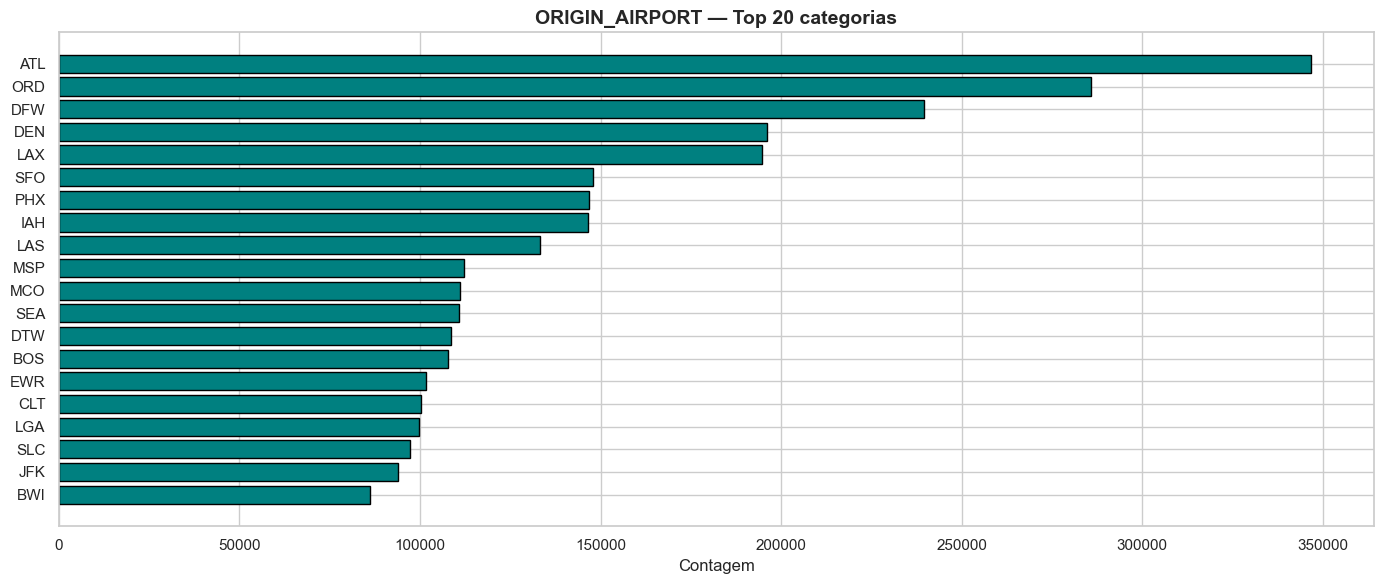


DESTINATION_AIRPORT  —  629 categorias únicas
Top 20:
DESTINATION_AIRPORT
ATL    346904
ORD    285906
DFW    239582
DEN    196010
LAX    194696
SFO    147966
PHX    146812
IAH    146683
LAS    133198
MSP    112128
MCO    110980
SEA    110907
DTW    108398
BOS    107851
EWR    101830
CLT    100322
LGA     99581
SLC     97193
JFK     93809
BWI     86085

⚠ 601 categorias com <1% dos registros (candidatas a agrupamento/remoção)


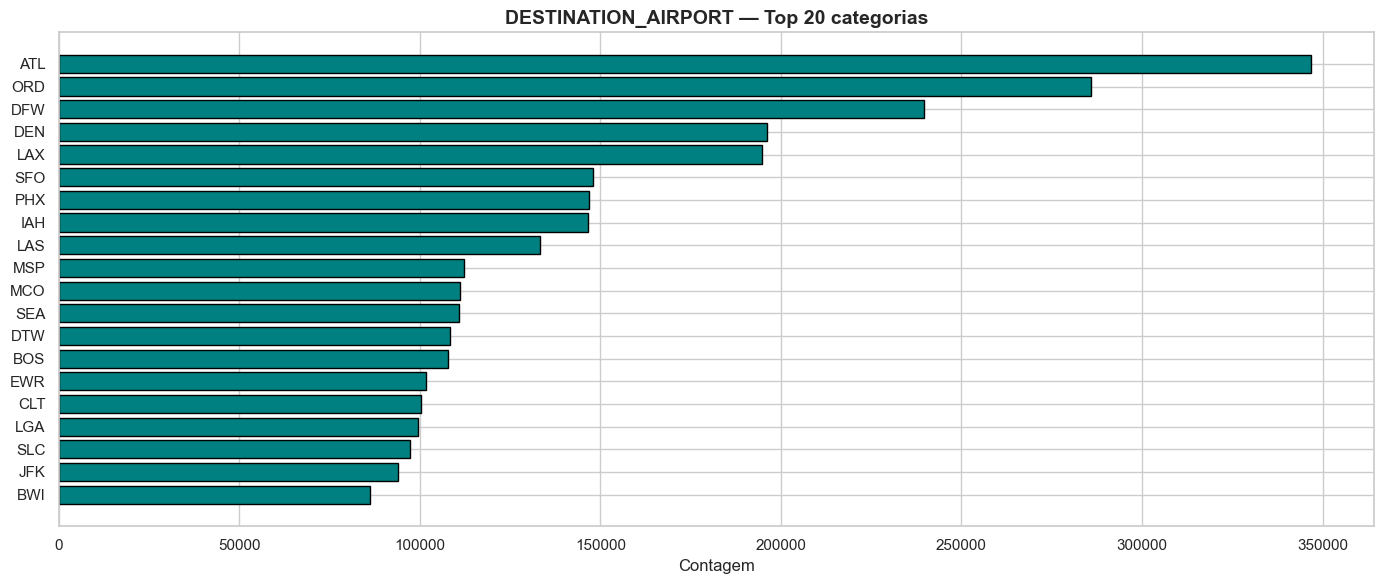


ORIGIN_AIRPORT_NAME  —  322 categorias únicas
Top 20:
ORIGIN_AIRPORT_NAME
Hartsfield-Jackson Atlanta International Airport                          346836
Chicago O'Hare International Airport                                      285884
Dallas/Fort Worth International Airport                                   239551
Denver International Airport                                              196055
Los Angeles International Airport                                         194673
San Francisco International Airport                                       148008
Phoenix Sky Harbor International Airport                                  146815
George Bush Intercontinental Airport                                      146622
McCarran International Airport                                            133181
Minneapolis-Saint Paul International Airport                              112117
Orlando International Airport                                             110982
Seattle-Tacoma International Airpo

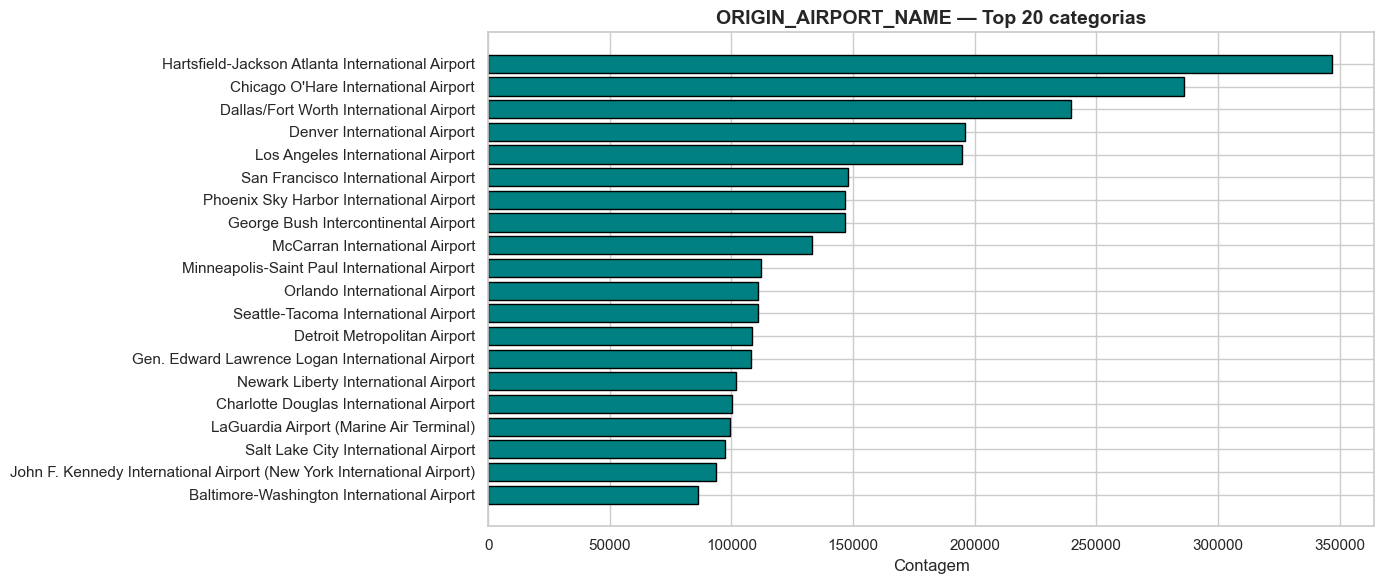


ORIGIN_CITY  —  308 categorias únicas
Top 20:
ORIGIN_CITY
Chicago              366770
Atlanta              346836
Dallas-Fort Worth    239551
Houston              198664
Denver               196055
Los Angeles          194673
New York             193416
San Francisco        148008
Phoenix              146815
Las Vegas            133181
Minneapolis          112117
Orlando              110982
Seattle              110899
Detroit              108500
Boston               107847
Newark               101772
Charlotte            100324
Salt Lake City        97210
Baltimore             86079
Arlington             73794

⚠ 282 categorias com <1% dos registros (candidatas a agrupamento/remoção)


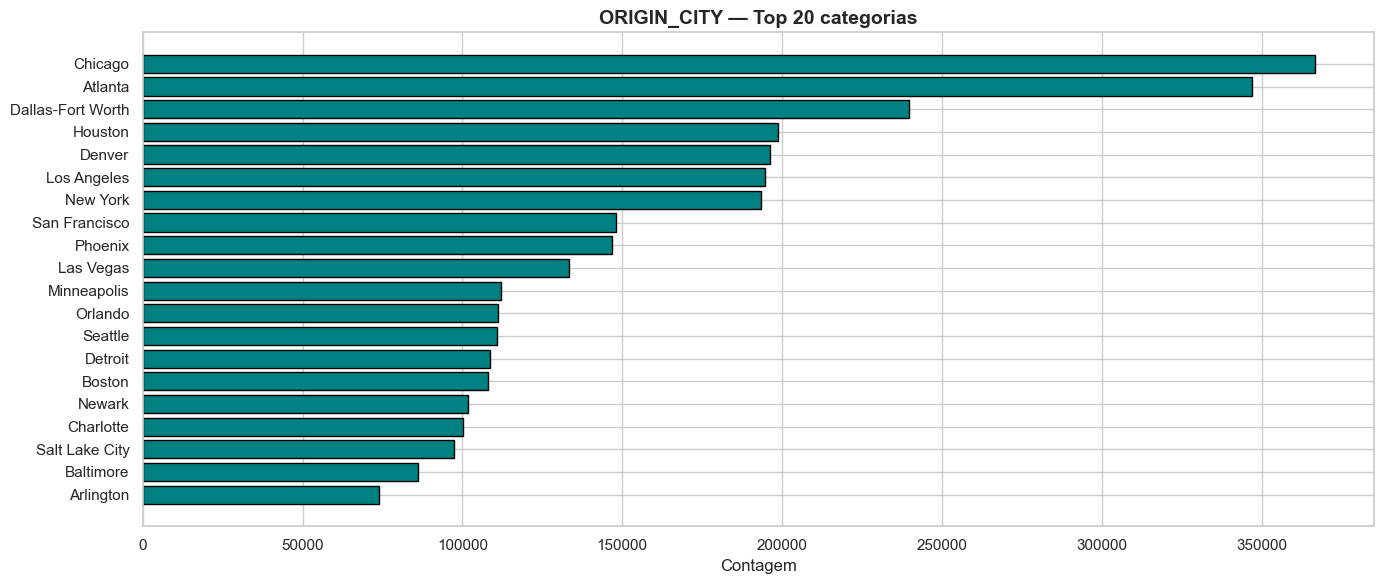


ORIGIN_STATE  —  54 categorias únicas
Top 20:
ORIGIN_STATE
CA    647911
TX    631124
FL    415586
IL    381644
GA    360496
NY    246235
CO    215451
AZ    165469
NC    146906
NV    146723
VA    138577
MI    137033
WA    123548
MN    118701
MA    109290
NJ    108174
PA     99995
UT     99972
MO     93838
HI     91181

⚠ 30 categorias com <1% dos registros (candidatas a agrupamento/remoção)


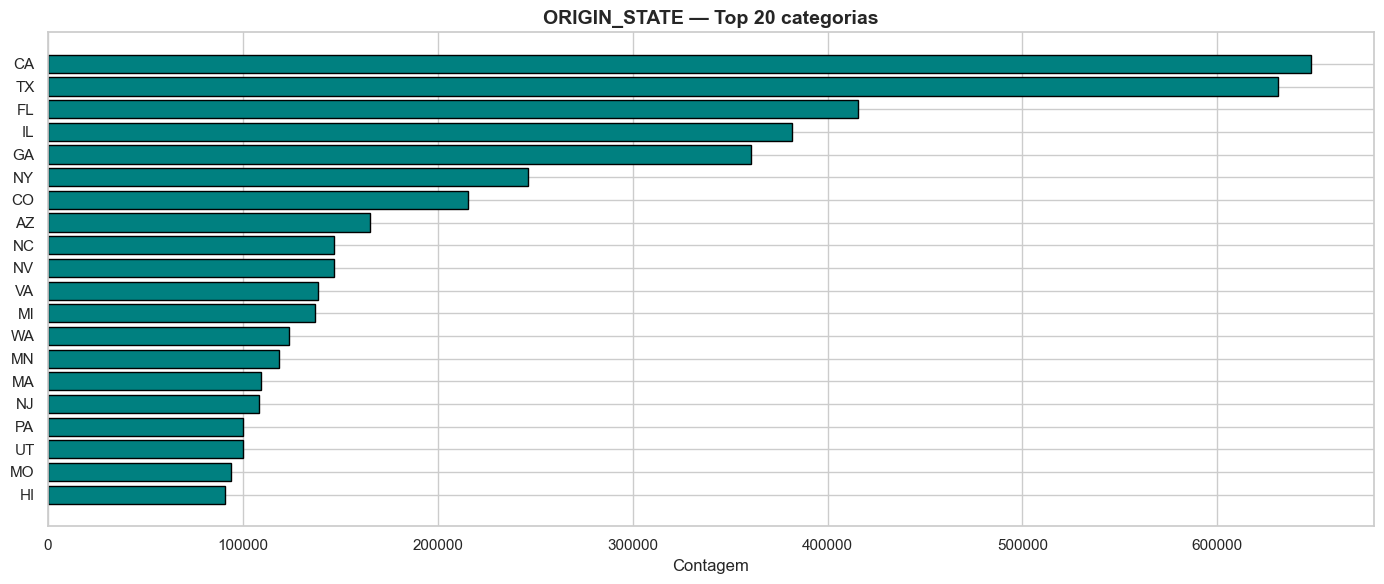


DEST_AIRPORT_NAME  —  322 categorias únicas
Top 20:
DEST_AIRPORT_NAME
Hartsfield-Jackson Atlanta International Airport                          346904
Chicago O'Hare International Airport                                      285906
Dallas/Fort Worth International Airport                                   239582
Denver International Airport                                              196010
Los Angeles International Airport                                         194696
San Francisco International Airport                                       147966
Phoenix Sky Harbor International Airport                                  146812
George Bush Intercontinental Airport                                      146683
McCarran International Airport                                            133198
Minneapolis-Saint Paul International Airport                              112128
Orlando International Airport                                             110980
Seattle-Tacoma International Airport  

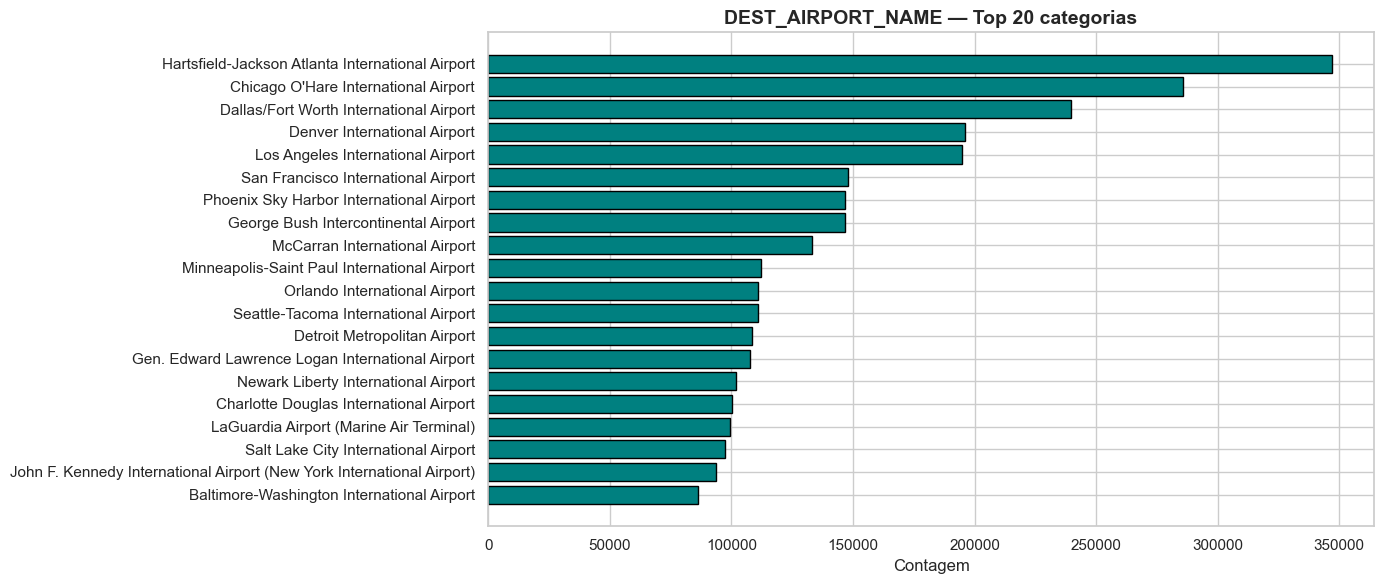


DEST_CITY  —  308 categorias únicas
Top 20:
DEST_CITY
Chicago              366790
Atlanta              346904
Dallas-Fort Worth    239582
Houston              198724
Denver               196010
Los Angeles          194696
New York             193390
San Francisco        147966
Phoenix              146812
Las Vegas            133198
Minneapolis          112128
Orlando              110980
Seattle              110907
Detroit              108398
Boston               107851
Newark               101830
Charlotte            100322
Salt Lake City        97193
Baltimore             86085
Arlington             73799

⚠ 282 categorias com <1% dos registros (candidatas a agrupamento/remoção)


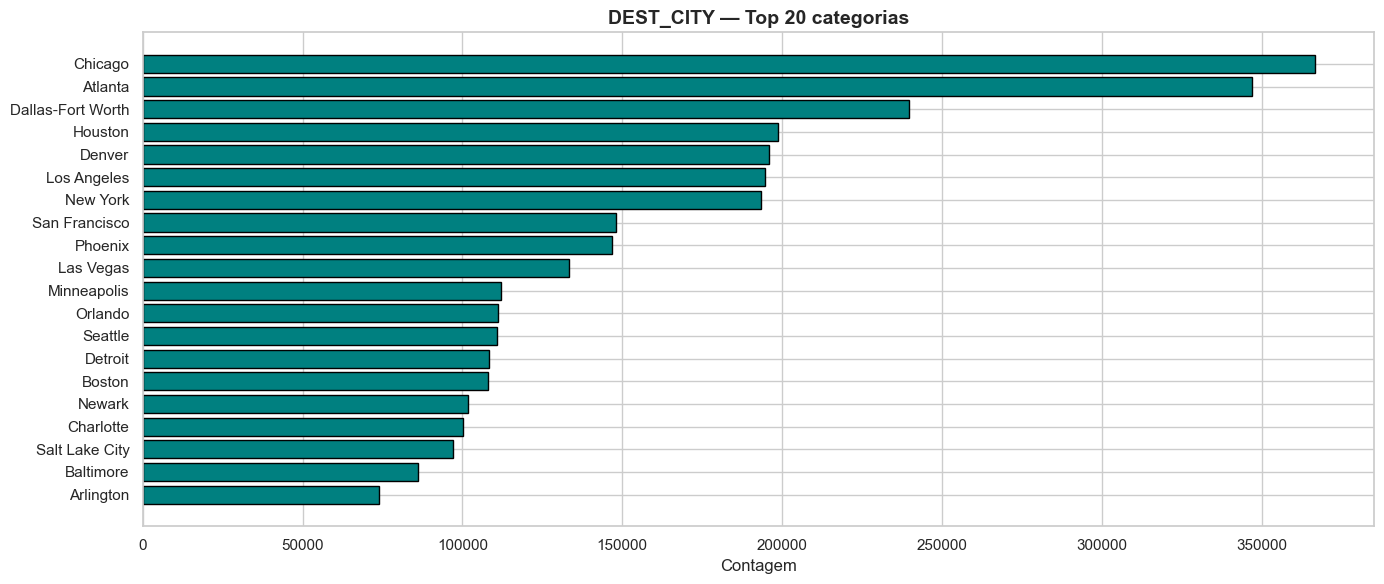


DEST_STATE  —  54 categorias únicas
Top 20:
DEST_STATE
CA    647899
TX    631214
FL    415554
IL    381666
GA    360563
NY    246231
CO    215404
AZ    165466
NC    146906
NV    146739
VA    138558
MI    136928
WA    123557
MN    118713
MA    109299
NJ    108237
PA    100000
UT     99955
MO     93828
HI     91176

⚠ 30 categorias com <1% dos registros (candidatas a agrupamento/remoção)


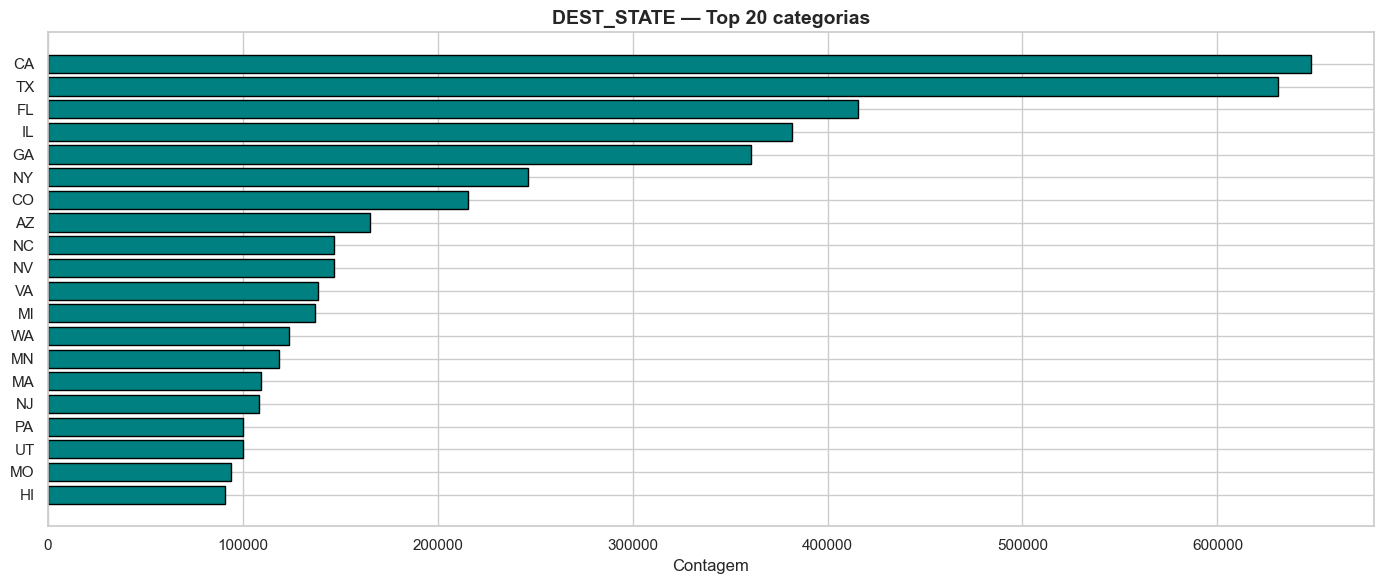

In [47]:
# Categóricas com alta cardinalidade — top 20 + resumo
if cat_high_card:
    for col in cat_high_card:
        vc = df[col].value_counts()
        print(f"\n{'='*60}")
        print(f"{col}  —  {vc.shape[0]} categorias únicas")
        print(f"{'='*60}")
        print(f"Top 20:")
        print(vc.head(20).to_string())
        # Categorias com menos de 1% dos registros
        rare = vc[vc / len(df) < 0.01]
        print(f"\n⚠ {len(rare)} categorias com <1% dos registros (candidatas a agrupamento/remoção)")

        # Plot top 20
        fig, ax = plt.subplots(figsize=(14, 6))
        top20 = vc.head(20)
        ax.barh(top20.index[::-1], top20.values[::-1], color='teal', edgecolor='black')
        ax.set_title(f'{col} — Top 20 categorias', fontsize=14, fontweight='bold')
        ax.set_xlabel('Contagem')
        plt.tight_layout()
        plt.show()

### Matriz de correlação de Pearson (variáveis numéricas)

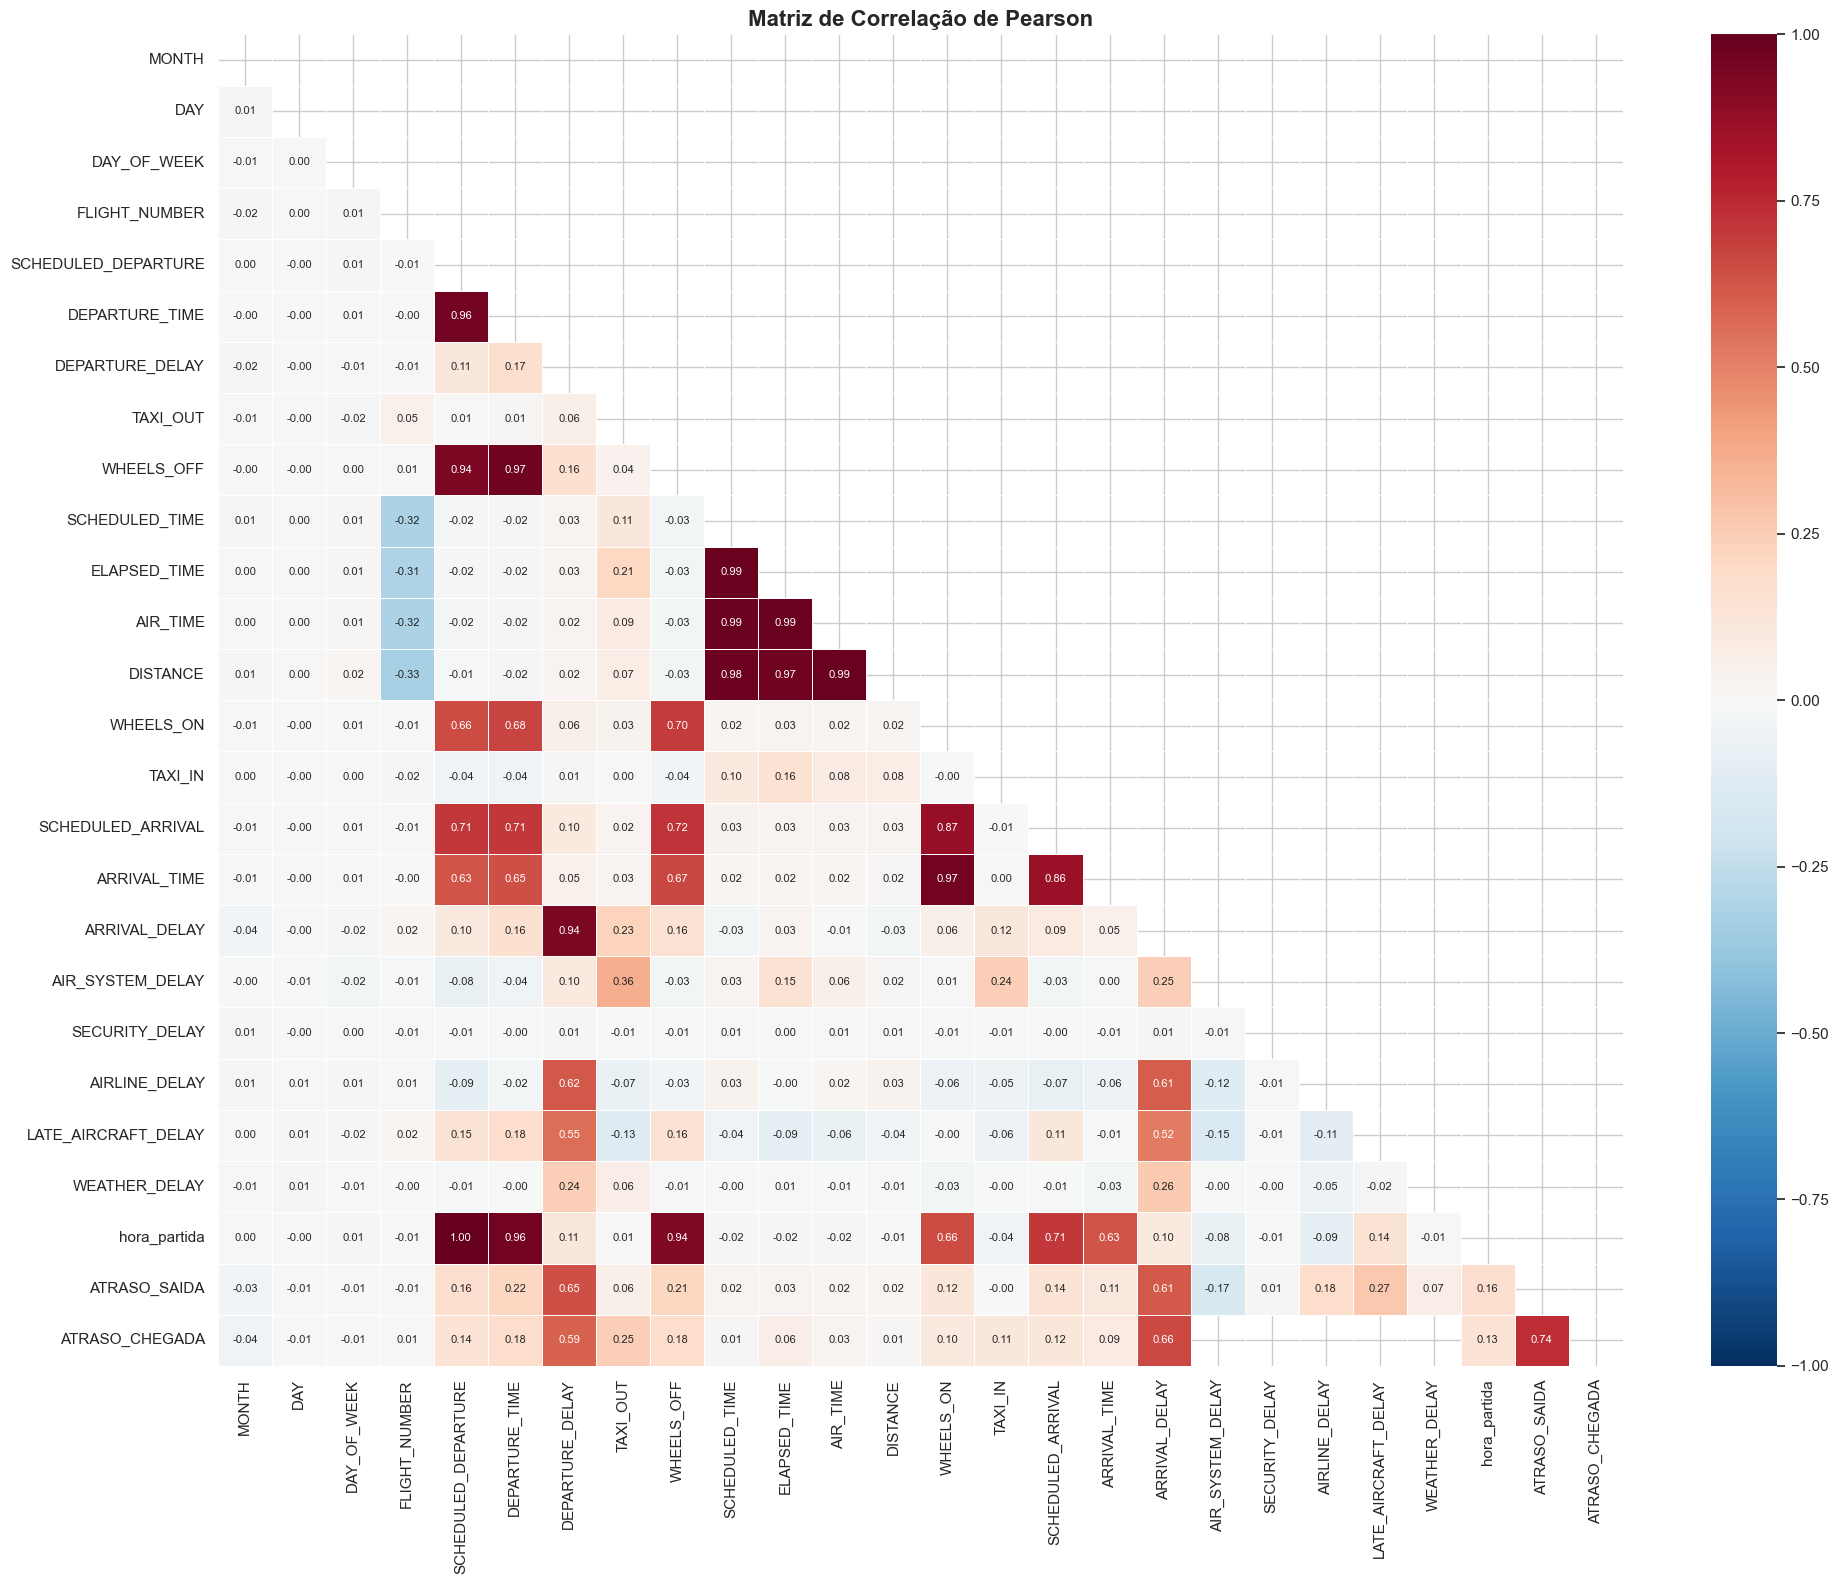

In [12]:
# Correlação de Pearson — incluindo os targets
corr_cols = num_features + ['ATRASO_SAIDA', 'ATRASO_CHEGADA']
corr_matrix = df[corr_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Matriz de Correlação de Pearson', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Top correlações com os targets
print("="*60)
print("Top correlações com ATRASO_SAIDA:")
print("="*60)
corr_saida = corr_matrix['ATRASO_SAIDA'].drop(['ATRASO_SAIDA', 'ATRASO_CHEGADA']).abs().sort_values(ascending=False)
print(corr_saida.to_string())

print(f"\n{'='*60}")
print("Top correlações com ATRASO_CHEGADA:")
print("="*60)
corr_chegada = corr_matrix['ATRASO_CHEGADA'].drop(['ATRASO_SAIDA', 'ATRASO_CHEGADA']).abs().sort_values(ascending=False)
print(corr_chegada.to_string())

Top correlações com ATRASO_SAIDA:
DEPARTURE_DELAY        0.645710
ARRIVAL_DELAY          0.611313
LATE_AIRCRAFT_DELAY    0.273293
DEPARTURE_TIME         0.217761
WHEELS_OFF             0.212389
AIRLINE_DELAY          0.182807
AIR_SYSTEM_DELAY       0.170850
SCHEDULED_DEPARTURE    0.164812
hora_partida           0.164480
SCHEDULED_ARRIVAL      0.139183
WHEELS_ON              0.117884
ARRIVAL_TIME           0.107443
WEATHER_DELAY          0.067977
TAXI_OUT               0.057031
MONTH                  0.033140
ELAPSED_TIME           0.025374
SCHEDULED_TIME         0.024366
DISTANCE               0.022724
AIR_TIME               0.019418
SECURITY_DELAY         0.012587
FLIGHT_NUMBER          0.011266
DAY_OF_WEEK            0.007714
DAY                    0.005906
TAXI_IN                0.003776

Top correlações com ATRASO_CHEGADA:
ARRIVAL_DELAY          0.663717
DEPARTURE_DELAY        0.586575
TAXI_OUT               0.249769
WHEELS_OFF             0.183399
DEPARTURE_TIME         0.182949
S

### Cruzamento das variáveis categóricas com o target

Calcular a **taxa de atraso** por categoria para identificar quais variáveis categóricas são mais explicativas.


######################################################################
 TARGET: ATRASO_SAIDA
######################################################################


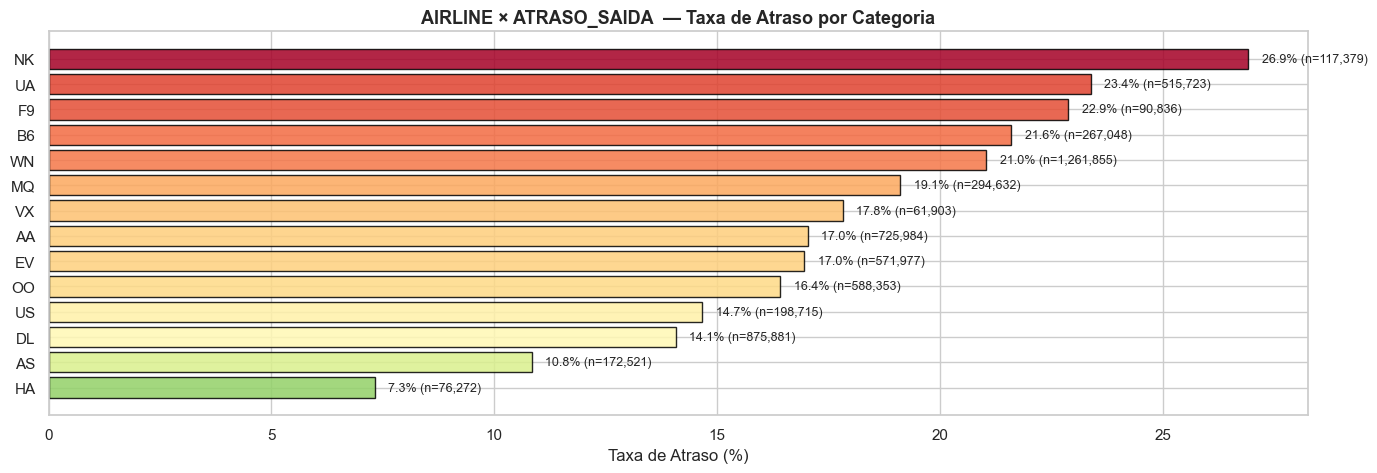

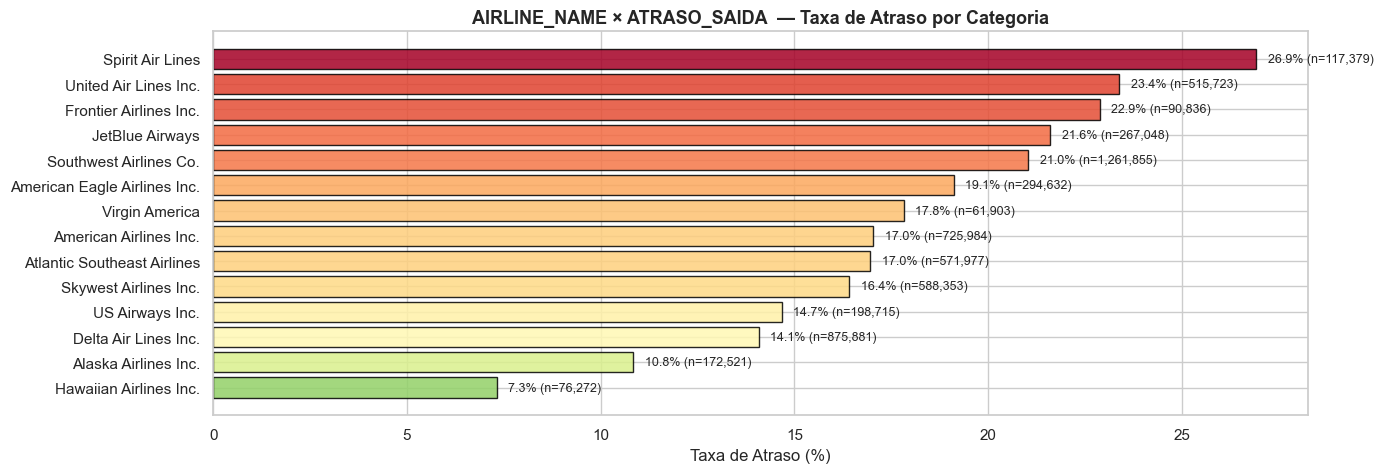

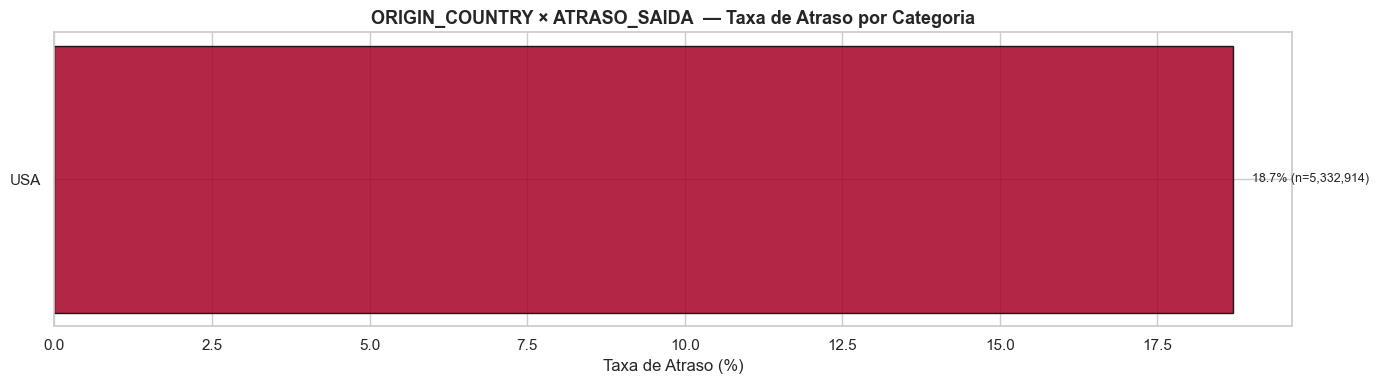

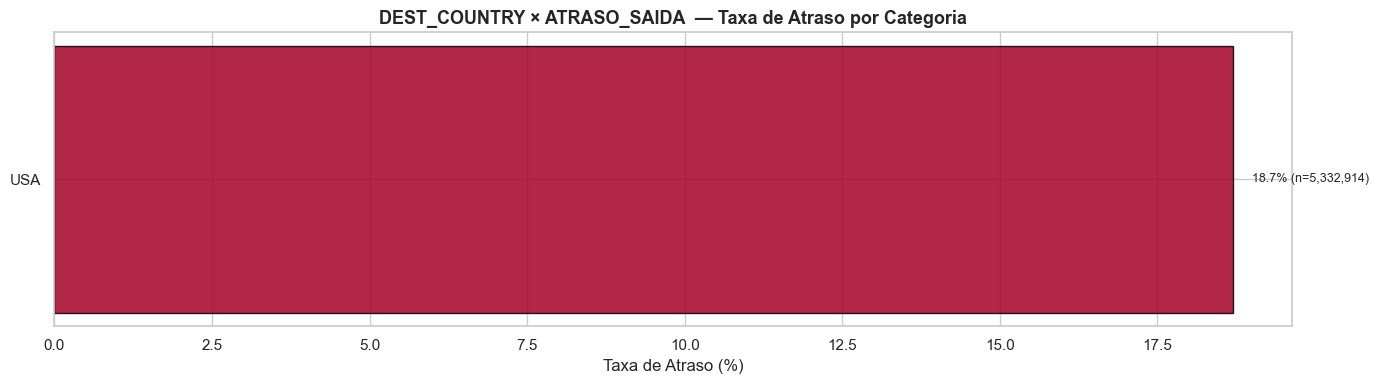

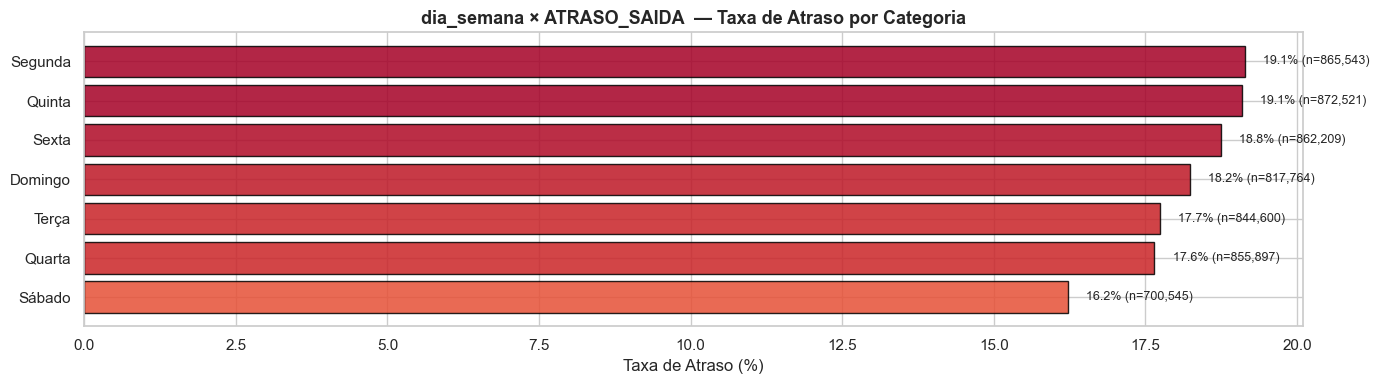

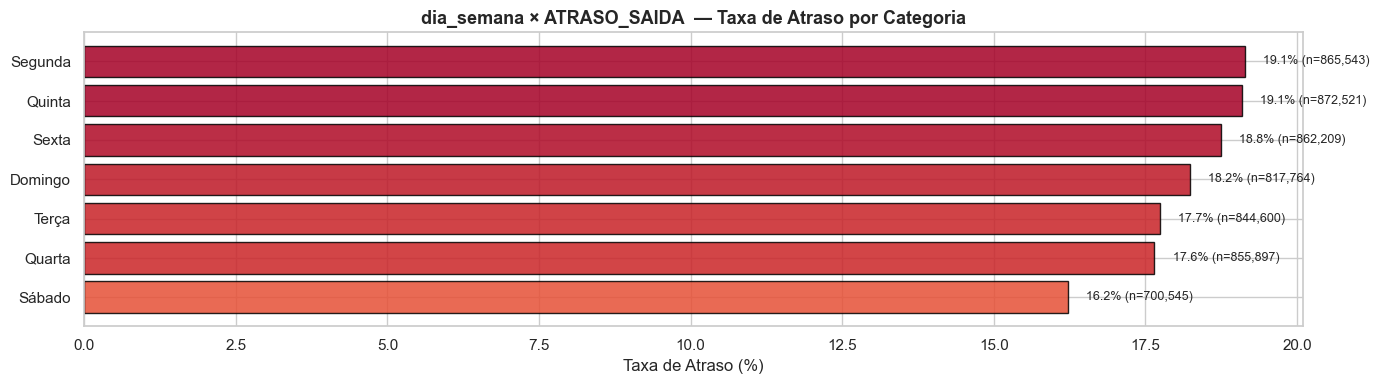

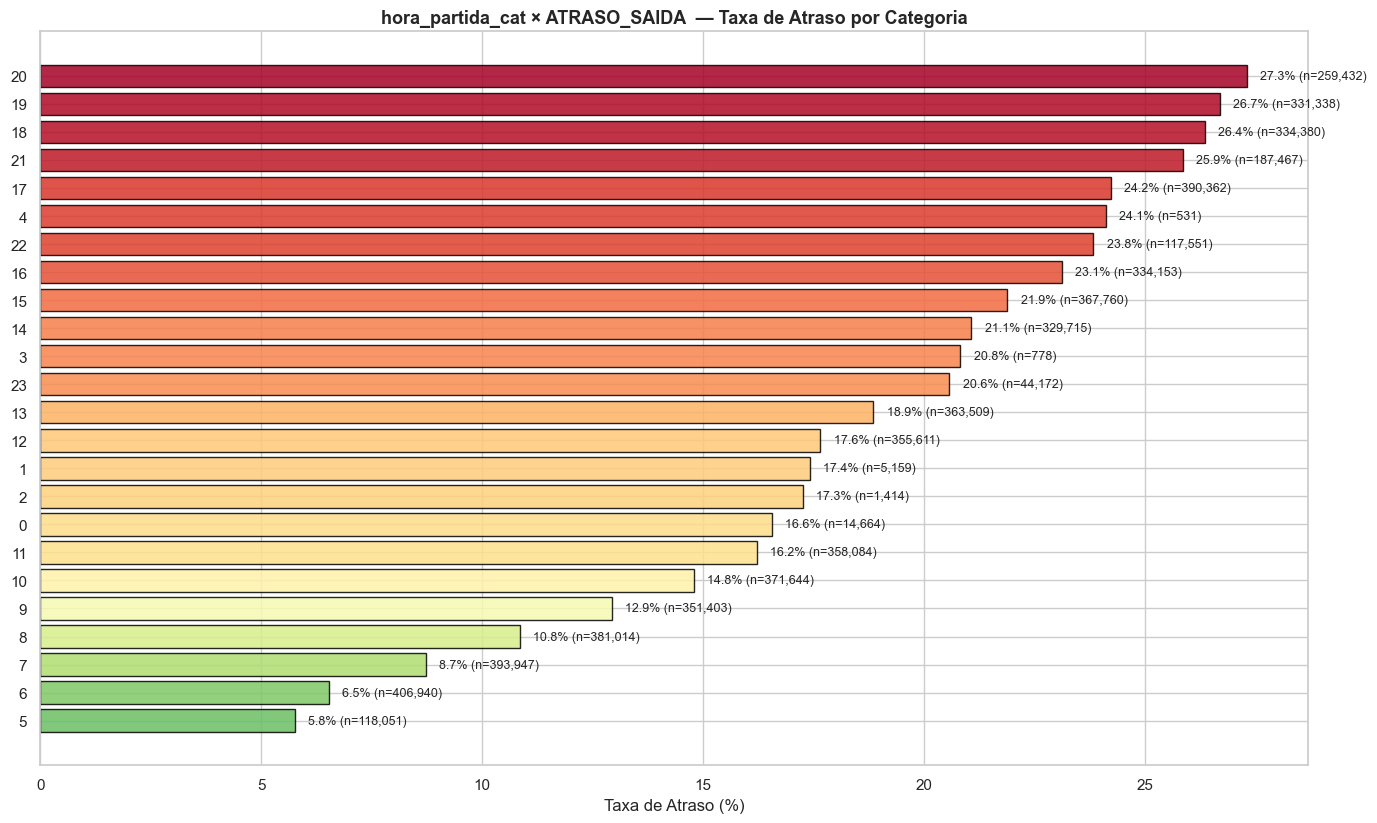


######################################################################
 TARGET: ATRASO_CHEGADA
######################################################################


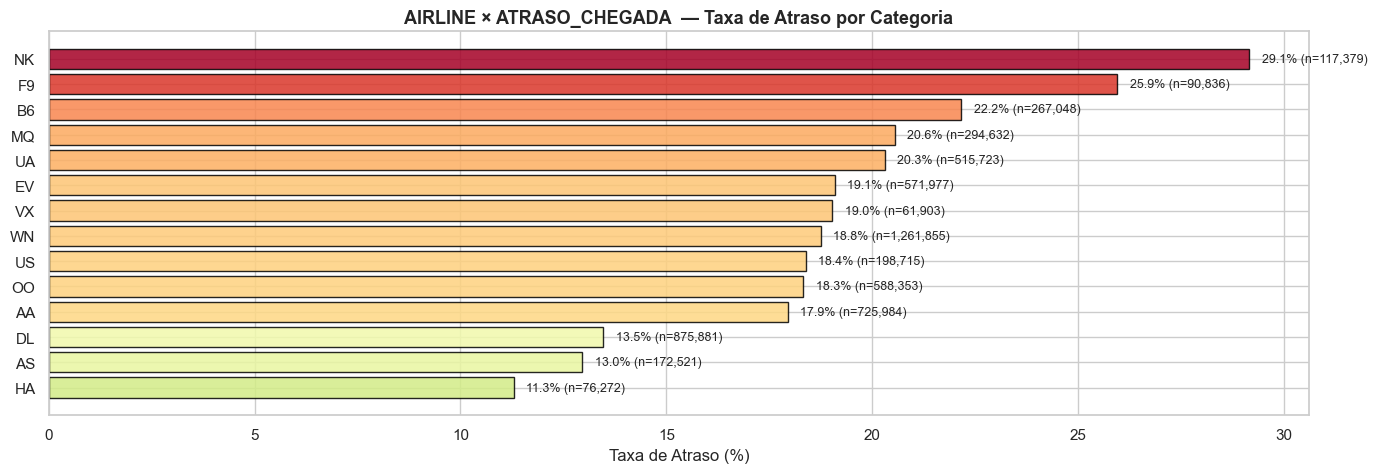

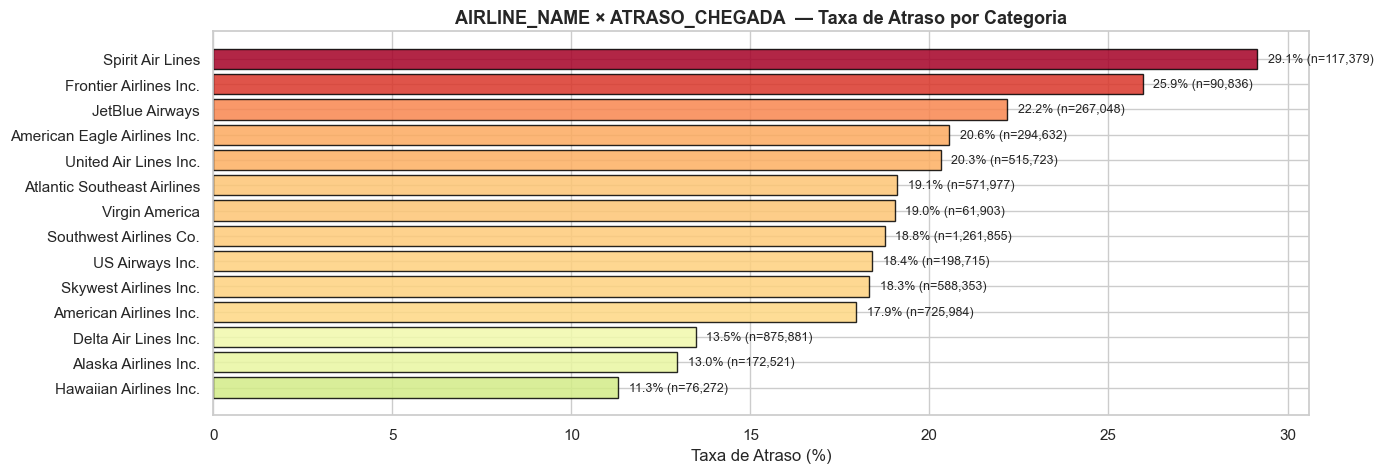

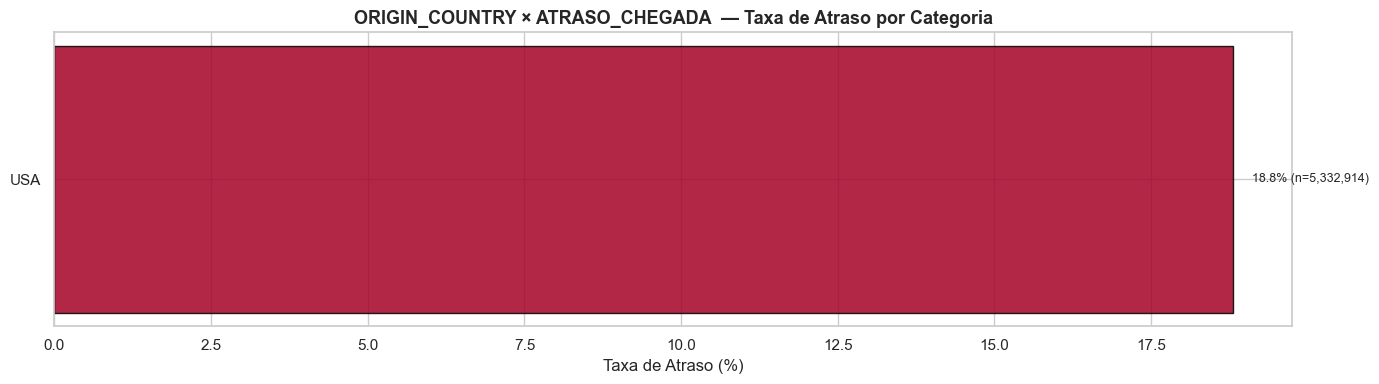

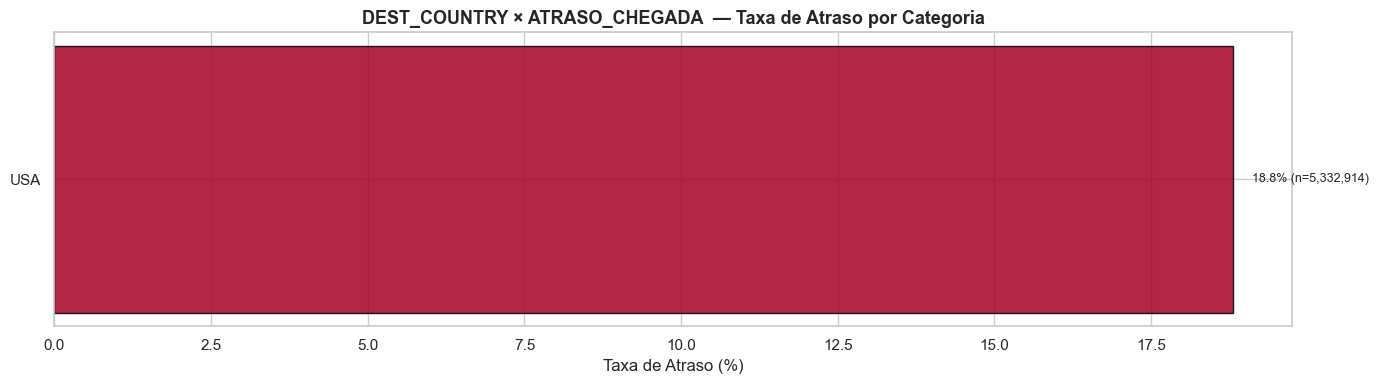

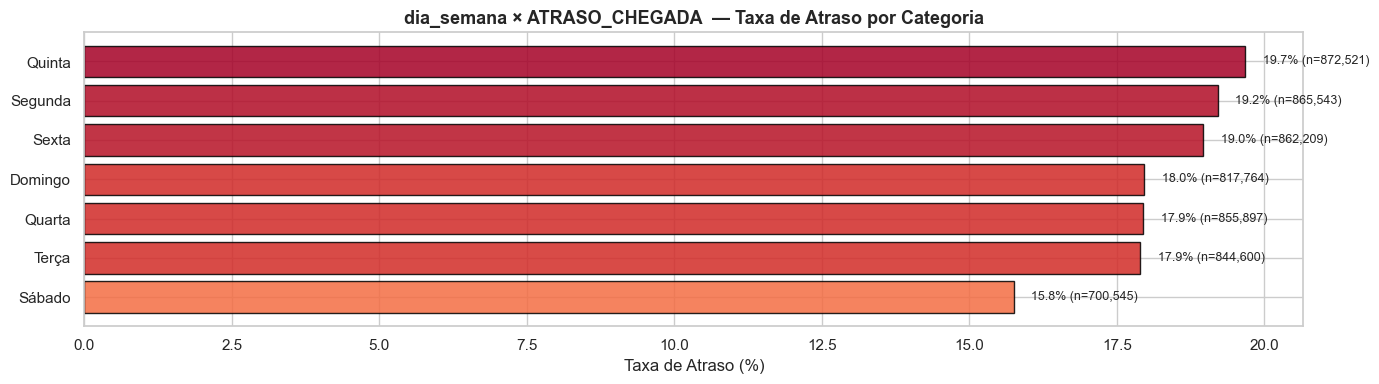

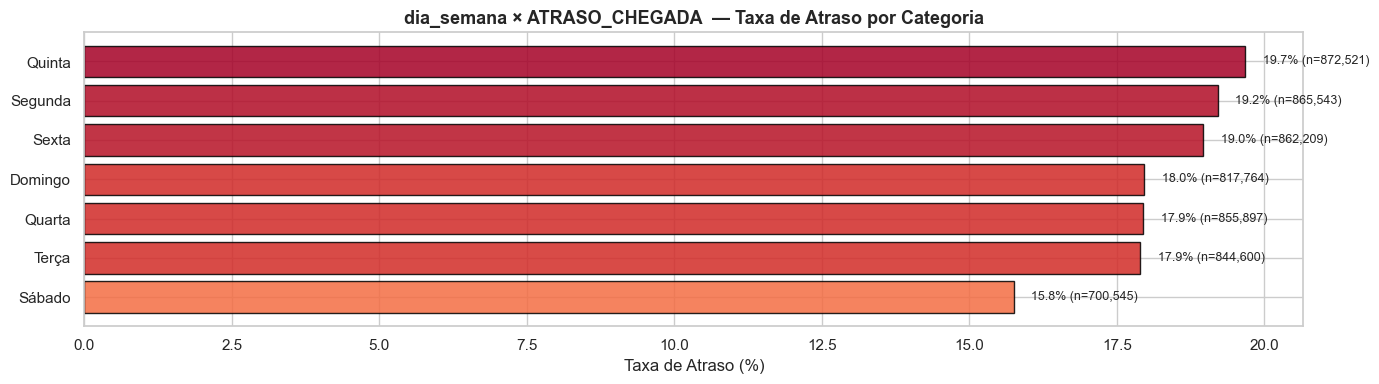

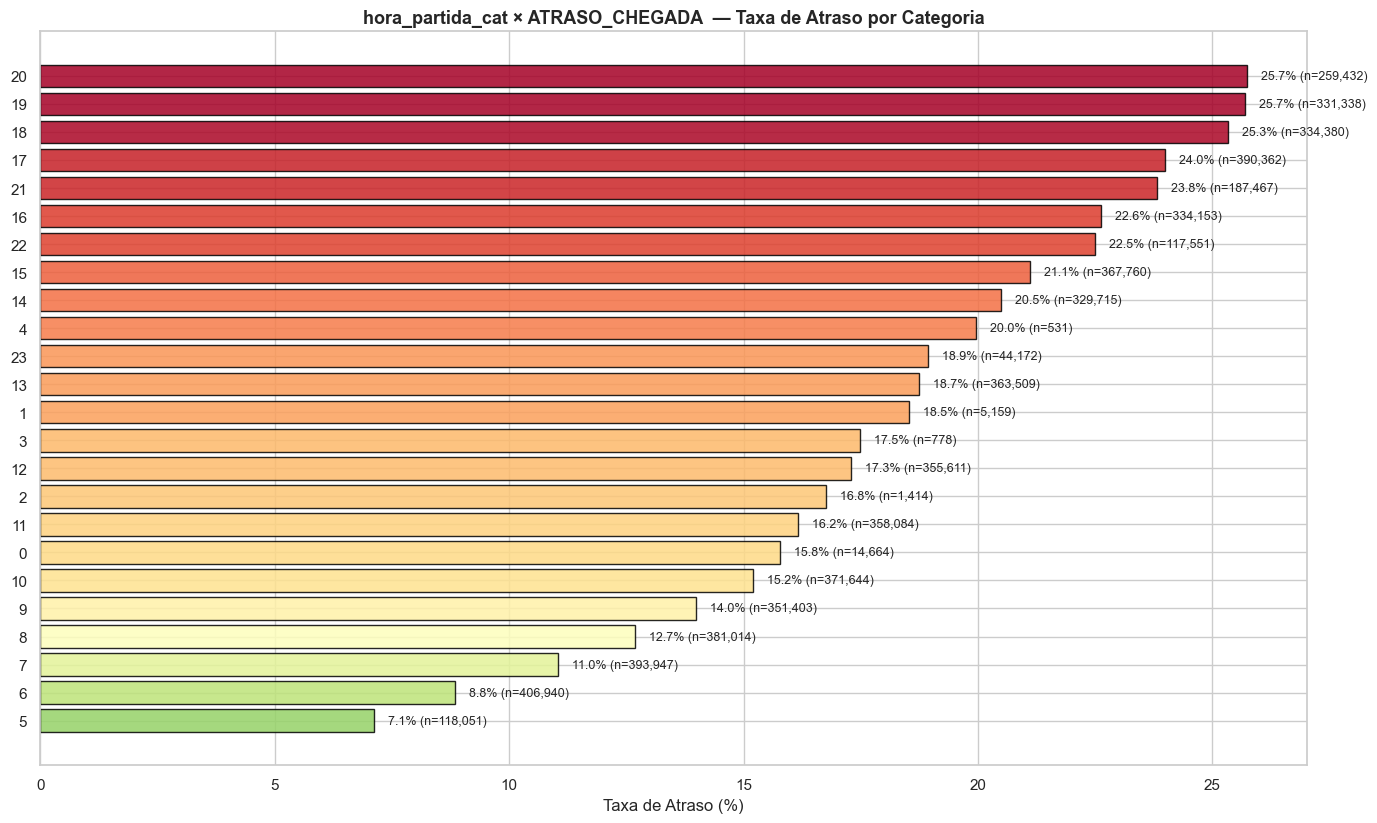

In [14]:
# Taxa de atraso por categoria (baixa cardinalidade + dia_semana + hora_partida)
cat_analysis = cat_low_card + ['dia_semana']  # dia_semana é categórica de interesse
# Adicionar hora_partida como categórica se não está em cat_cols
if 'hora_partida' in num_cols:
    df['hora_partida_cat'] = df['hora_partida'].astype(str)
    cat_analysis.append('hora_partida_cat')

# Remover CANCELLATION_REASON (muito nulo) se existir
cat_analysis = [c for c in cat_analysis if c in df.columns and c != 'CANCELLATION_REASON']

for target in ['ATRASO_SAIDA', 'ATRASO_CHEGADA']:
    print(f"\n{'#'*70}")
    print(f" TARGET: {target}")
    print(f"{'#'*70}")

    for col in cat_analysis:
        agg = df.groupby(col)[target].agg(['mean', 'count']).sort_values('mean', ascending=False)
        agg.columns = ['taxa_atraso', 'volume']
        agg['taxa_atraso_pct'] = (agg['taxa_atraso'] * 100).round(2)

        # Plot
        fig, ax1 = plt.subplots(figsize=(14, max(4, len(agg)*0.35)))

        # Ordenar por taxa de atraso
        agg_sorted = agg.sort_values('taxa_atraso', ascending=True)

        colors = plt.cm.RdYlGn_r(agg_sorted['taxa_atraso'] / agg_sorted['taxa_atraso'].max())
        ax1.barh(agg_sorted.index.astype(str), agg_sorted['taxa_atraso_pct'],
                 color=colors, edgecolor='black', alpha=0.85)
        ax1.set_xlabel('Taxa de Atraso (%)')
        ax1.set_title(f'{col} × {target}  — Taxa de Atraso por Categoria',
                       fontsize=13, fontweight='bold')

        # Anotar volume
        for idx, row in agg_sorted.iterrows():
            ax1.text(row['taxa_atraso_pct'] + 0.3, str(idx),
                     f"{row['taxa_atraso_pct']:.1f}% (n={row['volume']:,.0f})",
                     va='center', fontsize=9)

        plt.tight_layout()
        plt.show()

In [15]:
# Poder explicativo — variação da taxa de atraso entre categorias (range e std)
print("="*70)
print("PODER EXPLICATIVO DAS CATEGÓRICAS (variação da taxa de atraso)")
print("="*70)

for target in ['ATRASO_SAIDA', 'ATRASO_CHEGADA']:
    rows = []
    for col in cat_analysis:
        rates = df.groupby(col)[target].mean()
        rows.append({
            'Variável': col,
            'Target': target,
            'N_Categorias': rates.shape[0],
            'Taxa_Mín (%)': round(rates.min()*100, 2),
            'Taxa_Máx (%)': round(rates.max()*100, 2),
            'Range (pp)': round((rates.max() - rates.min())*100, 2),
            'Std (pp)': round(rates.std()*100, 2)
        })
    df_power = pd.DataFrame(rows).sort_values('Range (pp)', ascending=False)
    print(f"\n--- {target} ---")
    print(df_power.to_string(index=False))

PODER EXPLICATIVO DAS CATEGÓRICAS (variação da taxa de atraso)

--- ATRASO_SAIDA ---
        Variável       Target  N_Categorias  Taxa_Mín (%)  Taxa_Máx (%)  Range (pp)  Std (pp)
hora_partida_cat ATRASO_SAIDA            24          5.76         27.31       21.55      6.32
    AIRLINE_NAME ATRASO_SAIDA            14          7.32         26.92       19.60      5.20
         AIRLINE ATRASO_SAIDA            14          7.32         26.92       19.60      5.20
      dia_semana ATRASO_SAIDA             7         16.22         19.14        2.92      1.03
      dia_semana ATRASO_SAIDA             7         16.22         19.14        2.92      1.03
  ORIGIN_COUNTRY ATRASO_SAIDA             1         18.70         18.70        0.00       NaN
    DEST_COUNTRY ATRASO_SAIDA             1         18.70         18.70        0.00       NaN

--- ATRASO_CHEGADA ---
        Variável         Target  N_Categorias  Taxa_Mín (%)  Taxa_Máx (%)  Range (pp)  Std (pp)
hora_partida_cat ATRASO_CHEGADA            

### Análise de nulos (quantidade e taxa)

In [48]:
# Tabela de nulos
null_counts = df.isnull().sum()
null_pct = (df.isnull().mean() * 100).round(2)

df_nulls = pd.DataFrame({
    'Nulos': null_counts,
    '% Nulos': null_pct
}).sort_values('% Nulos', ascending=False)

# Filtrar apenas colunas que possuem pelo menos 1 nulo
df_nulls_only = df_nulls[df_nulls['Nulos'] > 0]

print(f"Total de colunas com nulos: {len(df_nulls_only)} de {df.shape[1]}")
print(f"Total de registros: {len(df):,}\n")
df_nulls_only

Total de colunas com nulos: 30 de 48
Total de registros: 5,819,079



,Nulos,% Nulos
CANCELLATION_REASON,5729195,98.46
SECURITY_DELAY,4755640,81.72
WEATHER_DELAY,4755640,81.72
LATE_AIRCRAFT_DELAY,4755640,81.72
AIRLINE_DELAY,4755640,81.72
AIR_SYSTEM_DELAY,4755640,81.72
ORIGIN_LONGITUDE,490770,8.43
ORIGIN_LATITUDE,490770,8.43
DEST_LATITUDE,490775,8.43
DEST_LONGITUDE,490775,8.43


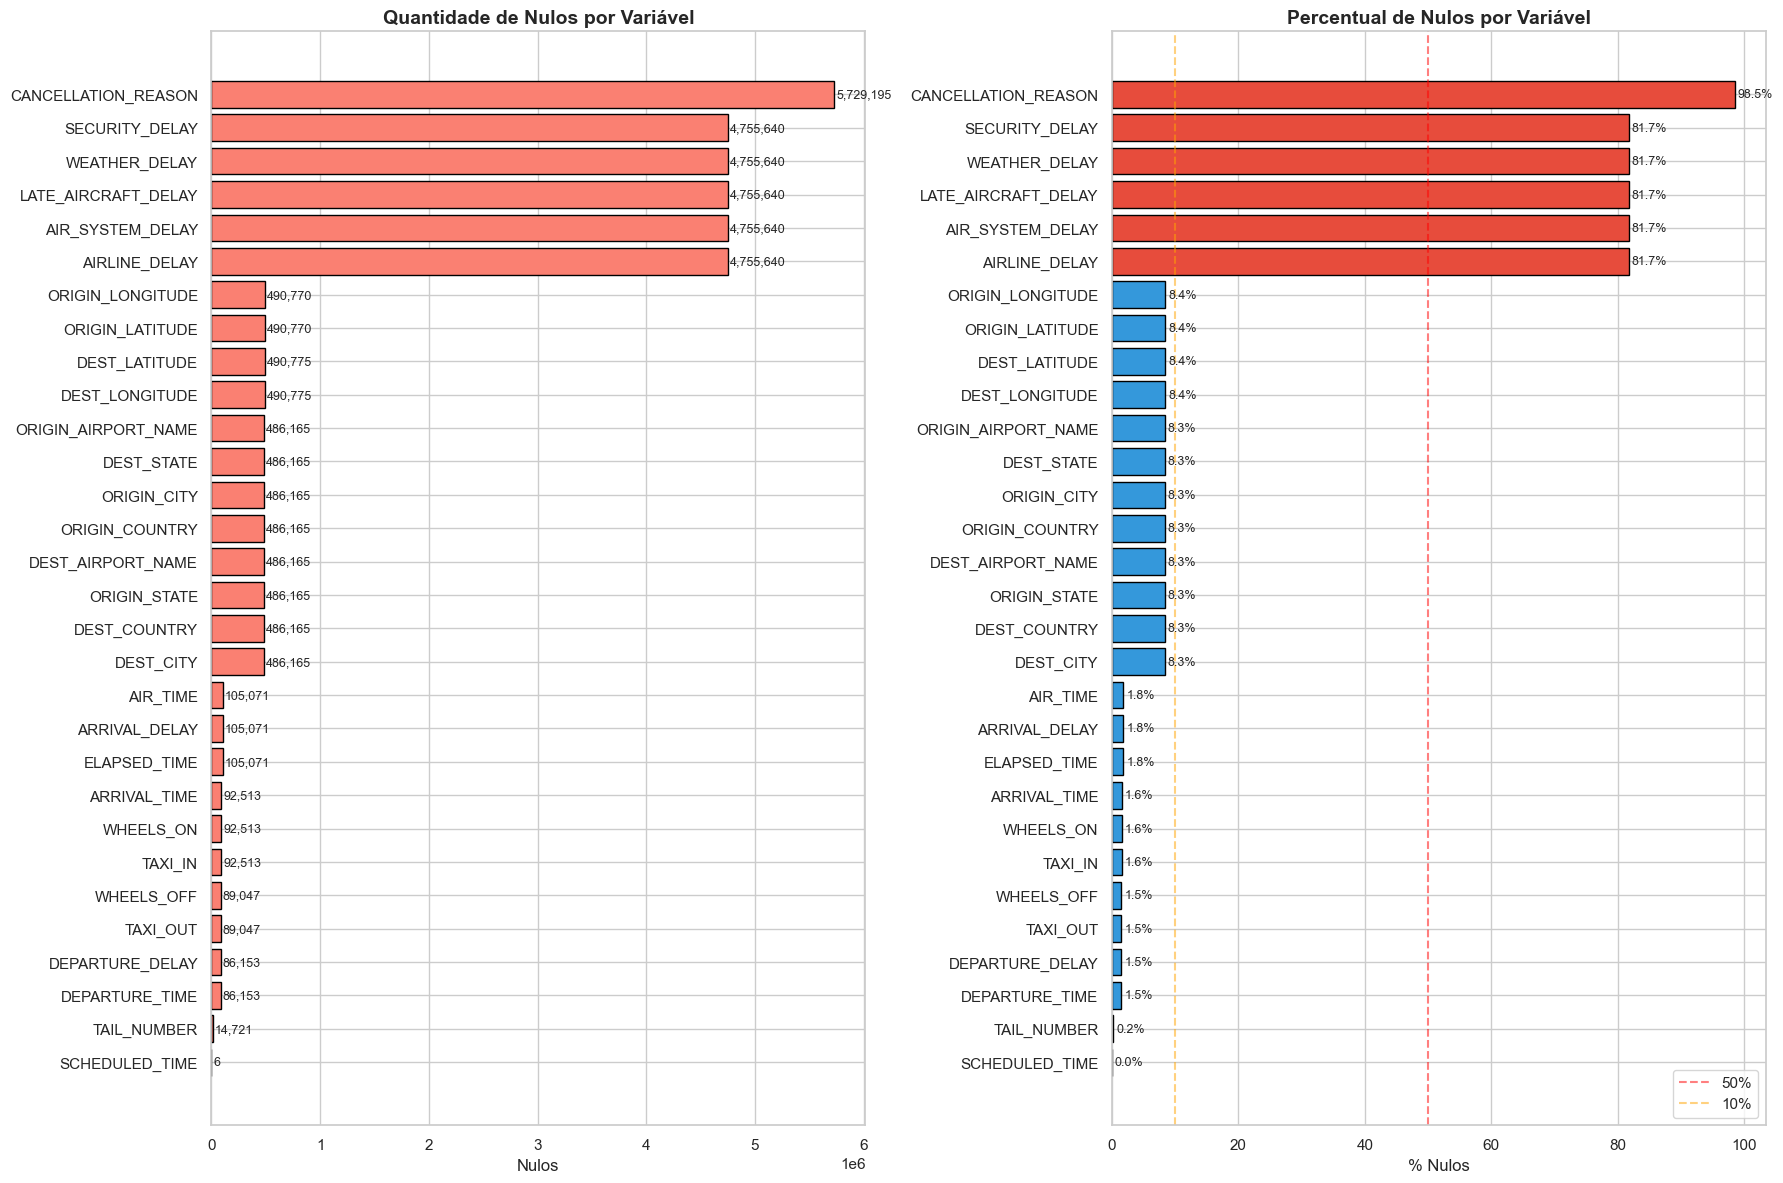

In [17]:
# Visualização dos nulos
if len(df_nulls_only) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, max(5, len(df_nulls_only)*0.4)))

    # Barplot — quantidade
    ax1 = axes[0]
    ax1.barh(df_nulls_only.index[::-1], df_nulls_only['Nulos'][::-1],
             color='salmon', edgecolor='black')
    ax1.set_title('Quantidade de Nulos por Variável', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Nulos')
    for i, (idx, row) in enumerate(df_nulls_only[::-1].iterrows()):
        ax1.text(row['Nulos'] + len(df)*0.003, i, f"{row['Nulos']:,.0f}",
                 va='center', fontsize=9)

    # Barplot — percentual
    ax2 = axes[1]
    colors = ['#e74c3c' if p > 50 else '#f39c12' if p > 10 else '#3498db'
              for p in df_nulls_only['% Nulos'][::-1]]
    ax2.barh(df_nulls_only.index[::-1], df_nulls_only['% Nulos'][::-1],
             color=colors, edgecolor='black')
    ax2.set_title('Percentual de Nulos por Variável', fontsize=14, fontweight='bold')
    ax2.set_xlabel('% Nulos')
    ax2.axvline(50, color='red', linestyle='--', alpha=0.5, label='50%')
    ax2.axvline(10, color='orange', linestyle='--', alpha=0.5, label='10%')
    ax2.legend()
    for i, (idx, row) in enumerate(df_nulls_only[::-1].iterrows()):
        ax2.text(row['% Nulos'] + 0.5, i, f"{row['% Nulos']:.1f}%",
                 va='center', fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("✅ Nenhuma coluna com valores nulos!")

## Relatório

### Dados gerais

- Dataset com ~5.8M de voos domesticos dos EUA em 2015.
- 30 de 48 colunas possuem pelo menos 1 valor nulo.
- 89.884 voos cancelados (~1.5%) e registros de voos desviados (DIVERTED).
- Targets criados: `ATRASO_SAIDA` e `ATRASO_CHEGADA` (>=10 min).
- Concordancia entre os dois targets: ~89% -- existem cenarios divergentes suficientes para justificar modelagem separada.


### Tratamento de nulos

| Faixa de nulos | Acao | Colunas afetadas |
|---|---|---|
| **>80% nulos** | **Dropar a coluna** | `CANCELLATION_REASON` (98.5%), `SECURITY_DELAY` (81.7%), `WEATHER_DELAY` (81.7%), `LATE_AIRCRAFT_DELAY` (81.7%), `AIRLINE_DELAY` (81.7%), `AIR_SYSTEM_DELAY` (81.7%) |
| **~8% nulos** | Imputar ou investigar join com airports | `ORIGIN_LONGITUDE`, `ORIGIN_LATITUDE`, `DEST_LATITUDE`, `DEST_LONGITUDE`, `DEST_CITY`, `DEST_AIRPORT_NAME`, `ORIGIN_COUNTRY`, `ORIGIN_STATE`, `ORIGIN_AIRPORT_NAME`, `ORIGIN_CITY`, `DEST_COUNTRY`, `DEST_STATE` |
| **1-2% nulos** | Imputar (mediana p/ numericas, moda p/ categoricas) ou dropar registros | `ARRIVAL_DELAY`, `AIR_TIME`, `ELAPSED_TIME`, `TAXI_IN`, `WHEELS_ON`, `ARRIVAL_TIME`, `TAXI_OUT`, `WHEELS_OFF`, `DEPARTURE_DELAY`, `DEPARTURE_TIME` |
| **<1% nulos** | Imputar valor ou dropar registros | `TAIL_NUMBER` (0.25%), `SCHEDULED_TIME` (~0%) |


### Colunas a dropar -- Informacao nula ou redundante

As seguintes colunas serao removidas por nao agregarem poder preditivo:

| Coluna | Motivo |
|---|---|
| `YEAR` | Apenas 1 valor (2015) -- variancia zero |
| `ORIGIN_COUNTRY` | Apenas 1 valor ("USA") -- variancia zero |
| `DEST_COUNTRY` | Apenas 1 valor ("USA") -- variancia zero |
| `TAIL_NUMBER` | Identificador de aeronave -- cardinalidade altissima, pouco generalizavel |
| `CANCELLATION_REASON` | 98.5% nulo -- ja dropada pela regra de nulos |
| `FLIGHT_NUMBER` | Identificador do voo -- nao generalizavel para novos dados |
| `DEPARTURE_TIME` | Disponivel somente apos o evento -- data leakage para atraso de saida |
| `ARRIVAL_TIME` | Idem -- leakage para atraso de chegada |
| `WHEELS_OFF`, `WHEELS_ON` | Horarios reais em voo -- leakage |
| `ELAPSED_TIME`, `AIR_TIME` | Tempo real de voo -- leakage (so conhecidos apos pouso) |
| `TAXI_IN`, `TAXI_OUT` | Tempo real de taxi -- leakage |
| `DIVERTED` | Consequencia, nao causa -- nao disponivel pre-voo |
| `AIRLINE_NAME` | Redundante com `AIRLINE` (codigo da companhia) |
| `ORIGIN_AIRPORT_NAME`, `DEST_AIRPORT_NAME` | Redundante com `ORIGIN_AIRPORT` / `DESTINATION_AIRPORT` |
| `ORIGIN_CITY`, `DEST_CITY` | Redundante com state + airport |
| Colunas de delay detalhado | `AIR_SYSTEM_DELAY`, `SECURITY_DELAY`, `AIRLINE_DELAY`, `LATE_AIRCRAFT_DELAY`, `WEATHER_DELAY` -- alem de >80% nulos, sao decomposicoes do atraso (leakage direto) |

> **OBS:** para evitar data lackage, devemos usar apenas variaveis conhecidas antes do voo decolar. Variaveis como DEPARTURE_TIME, TAXI_OUT, WHEELS_OFF, AIR_TIME etc. so existem apos o evento acontecer.


### Filtros no dataset

- **Remover voos cancelados** (`CANCELLED == 1`): sao ~90k registros (1.5%). Voo cancelado nao tem atraso de saida nem de chegada -- nao faz sentido para classificacao de atraso.
- **Remover voos desviados** (`DIVERTED == 1`): comportamento anomalo que polui o target de chegada.
- Apos filtrar, dropar as colunas `CANCELLED` e `DIVERTED` (ficam constantes = 0).


### Tratamento de outliers

Variaveis com maior concentracao de outliers (metodo IQR):

| Variavel | % Outliers |
|---|---|
| `DEPARTURE_DELAY` | 12.8% |
| `ARRIVAL_DELAY` | 9.0% |
| `DISTANCE` | 6.0% |
| `SCHEDULED_TIME` | 5.1% |

**Estrategia:** aplicar capping no p99. Preserva a informacao dos extremos sem deixar que valores absurdos dominem o treinamento. Para as variaveis de delay que serao descartadas por leakage, o capping so se aplica caso a analise de magnitude do atraso seja desejada em paralelo.


### Categoricas com baixa frequencia

- Para categorias com **<1% de frequencia** dentro de uma variavel, agrupar em categoria `"OUTROS"`.
- Relevante principalmente para:
  - `ORIGIN_AIRPORT` (628 categorias) e `DESTINATION_AIRPORT` (629 categorias) -- dezenas de aeroportos pequenos com volume minimo.
  - `ORIGIN_STATE` / `DEST_STATE` (54 categorias) -- territorios com pouquissimos voos.
- `AIRLINE` (14 categorias): provavelmente todas ficam, mas verificar se alguma tem <1%.


### Novas variaveis

| Nova Feature | Origem | Logica |
|---|---|---|
| `PERIODO_DIA` | `hora_partida` | Madrugada (0-5), Manha (6-11), Tarde (12-17), Noite (18-23) |
| `TIPO_DIA_SEMANA` | `DAY_OF_WEEK` / `dia_semana` | Comeco (Seg/Ter), Meio (Qua/Qui), Fim (Sex/Sab/Dom) |
| `FIM_DE_SEMANA` | `DAY_OF_WEEK` | Binario: 1 se Sabado ou Domingo |
| `ESTACAO` | `MONTH` | Inverno (12,1,2), Primavera (3,4,5), Verao (6,7,8), Outono (9,10,11) -- hemisferio norte |
| `ROTA` | `ORIGIN_AIRPORT` + `DESTINATION_AIRPORT` | Concatenar origem-destino para capturar rotas especificas com alto volume |
| `FAIXA_DISTANCIA` | `DISTANCE` | Curta (<500mi), Media (500-1500mi), Longa (>1500mi) |
| `HORA_PICO` | `hora_partida` | Binario: 1 se entre 6-9 ou 17-20 (horarios de pico aeroportuario) |
| `DIA_MES_GRUPO` | `DAY` | Comeco (1-10), Meio (11-20), Fim (21-31) |



### Resumo das variaveis candidatas para modelagem

Apos limpeza e feature engineering, as features candidatas serao:

**Numericas (originais):**
`MONTH`, `DAY`, `DAY_OF_WEEK`, `SCHEDULED_DEPARTURE`, `SCHEDULED_TIME`, `DISTANCE`, `SCHEDULED_ARRIVAL`, `hora_partida`, `ORIGIN_LATITUDE`, `ORIGIN_LONGITUDE`, `DEST_LATITUDE`, `DEST_LONGITUDE`

**Categoricas (para encoding):**
`AIRLINE`, `ORIGIN_AIRPORT`, `DESTINATION_AIRPORT`, `ORIGIN_STATE`, `DEST_STATE`, `dia_semana`

**Novas (a criar):**
`PERIODO_DIA`, `TIPO_DIA_SEMANA`, `FIM_DE_SEMANA`, `ESTACAO`, `FAIXA_DISTANCIA`, `HORA_PICO`, `ROTA`, `DIA_MES_GRUPO`

**Targets:**
- `ATRASO_SAIDA` -- modelo 1 (previsao pre-decolagem)
- `ATRASO_CHEGADA` -- modelo 2 (previsao pre-decolagem)